In [ ]:
import pandas as pd
from datetime import timedelta
import numpy as np
from collections import defaultdict
import joblib
import matplotlib.pyplot as plt
import seaborn as sns

import lightgbm as lgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import (roc_auc_score, accuracy_score, precision_score,
                             recall_score, f1_score, classification_report,
                             confusion_matrix, roc_curve, precision_recall_curve)
from sklearn.preprocessing import StandardScaler, OneHotEncoder

import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, TensorDataset

from collections import defaultdict
import random

In [ ]:
# Đường dẫn file (thay nếu cần)
DATA_PATH = '/content/drive/MyDrive/Khóa luận/dataset.xlsx'

df = pd.read_excel(DATA_PATH)

In [ ]:
df.head(10)

,invoice_number,invoice_no,customer_code,item_code,item_description,expiry_date,lot_no,warehouse_code,sales_date,quantity,...,tax_value,sales_district,credit_reason_code,credit_reason_description,ar_term,order_source,sales_type_code,sales_type_description,kenh_bh,transaction_type
0,4210184552,1214742989,30349141,21234176,SEBIONEX CLEANSING GEL 200ML,20250328,R22C32/22084002,3076,45141,-1,...,-39000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR
1,4210184561,1214742993,30340582,21234217,ENDOCARE C FERULIC EDAFENCE SERUM 30ML,20250730,22G471,3076,45141,-1,...,-150000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR
2,4210184552,1214742989,30349141,21234217,ENDOCARE C FERULIC EDAFENCE SERUM 30ML,20250730,22G471,3076,45141,-1,...,-150000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR
3,4210184552,1214742989,30349141,21234216,HELIOCARE 360 WATER GEL,20250630,22F380,3076,45141,-1,...,-117000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR
4,4210184561,1214742993,30340582,21234471,NOVOPHANE ENERGIZING SHAMPOO,20250430,R22D76/22096003,3076,45141,-1,...,-52000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR
5,4210184552,1214742989,30349141,21234211,DEPIWHI ADV INTEN ANTIBROW SPOT CRE 40ML,20250930,22I05,3076,45141,-1,...,-56000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR
6,4210184567,1214742968,30385684,21234216,HELIOCARE 360 WATER GEL,20250630,22F380,3076,45141,-1,...,-117000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR
7,4210184552,1214742989,30349141,21234471,NOVOPHANE ENERGIZING SHAMPOO,20250430,R22D76/22096003,3076,45141,-1,...,-52000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR
8,4210184561,1214742993,30340582,21234216,HELIOCARE 360 WATER GEL,20250630,22F380,3076,45141,-1,...,-117000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR
9,4210184567,1214742968,30385684,21234471,NOVOPHANE ENERGIZING SHAMPOO,20250430,R22D76/22096003,3076,45141,-1,...,-52000.0,HNO,R33,WRONG BOOKING-CUST,C012,MAIL,NOR,Normal Sales,ETC,CR


In [ ]:

print("Initial shape:", df.shape)
print("Data type:",df.info())



Initial shape: (1048575, 23)
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1048575 entries, 0 to 1048574
Data columns (total 23 columns):
 #   Column                     Non-Null Count    Dtype  
---  ------                     --------------    -----  
 0   invoice_number             1048575 non-null  int64  
 1   invoice_no                 1048575 non-null  int64  
 2   customer_code              1048575 non-null  int64  
 3   item_code                  1048575 non-null  object 
 4   item_description           1048575 non-null  object 
 5   expiry_date                1048575 non-null  int64  
 6   lot_no                     1048488 non-null  object 
 7   warehouse_code             1048575 non-null  int64  
 8   sales_date                 1048575 non-null  int64  
 9   quantity                   1048575 non-null  int64  
 10  selling_price              1048575 non-null  float64
 11  sales_value                1048575 non-null  int64  
 12  item_tax_rate              1048575 non-nu

In [ ]:


# Drop columns không cần
cols_to_drop = [
    "invoice_no",
    "item_description", "expiry_date",
    "kenh_bh",
    "item_tax_rate", "tax_value", "sales_type_description", "credit_reason_description"
]
df = df.drop(columns=cols_to_drop, errors="ignore")
print("Initial shape:", df.shape)

Initial shape: (1048575, 15)


In [ ]:
missing = df.isnull().sum()

missing_percent = (missing / len(df)) * 100

missing_table = pd.DataFrame({
    "Missing Count": missing,
    "Missing Percent": missing_percent
})

print(missing_table)

                    Missing Count  Missing Percent
invoice_number                  0         0.000000
customer_code                   0         0.000000
item_code                       0         0.000000
lot_no                         87         0.008297
warehouse_code                  0         0.000000
sales_date                      0         0.000000
quantity                        0         0.000000
selling_price                   0         0.000000
sales_value                     0         0.000000
sales_district                  0         0.000000
credit_reason_code         921777        87.907589
ar_term                         0         0.000000
order_source                  422         0.040245
sales_type_code                 0         0.000000
transaction_type                0         0.000000


In [ ]:
duplicates = df.duplicated().sum()

print("Number of duplicate rows:", duplicates)

Number of duplicate rows: 0


In [ ]:


#XỬ LÝ MISSING
missing_values = ["", " ", "NA", "N/A", "NULL", "null"]

df["order_source"] = (
    df["order_source"]
    .astype(str)
    .str.strip()
    .replace(missing_values, np.nan)
)

# Convert sales_date
df["sales_date"] = pd.to_datetime("1899-12-30") + pd.to_timedelta(df["sales_date"].astype("int"), unit="D")

# Tạo flag credit issue
df["has_credit_issue"] = df["credit_reason_code"].notna().astype(int)
df = df.drop(columns=["credit_reason_code"], errors="ignore")


# === FLAG RETURN CHÍNH XÁC DỰA VÀO TRANSACTION_TYPE ===
# "CR" = cancel (sales_value âm), "IV" = invoice (sales_value dương)
df['is_cancel'] = (df['transaction_type'] == 'CR').astype(int)
df['is_invoice'] = (df['transaction_type'] == 'IV').astype(int)


# Abs sales_value
df['abs_sales_value'] = df['sales_value'].abs()




In [ ]:
df = (
    df
    .groupby(
        [
            "invoice_number",
            "customer_code",
            "item_code",
            "sales_date",
            "sales_district",
            "warehouse_code",
            "selling_price",
            "transaction_type",
            "order_source",
            "sales_type_code",
            "ar_term"
        ],
        as_index=False
    )
    .agg(
        {
            "quantity": "sum",
            "sales_value": "sum",
            "abs_sales_value": "sum",
            "is_cancel": "max",
            "is_invoice": "max",
            "has_credit_issue": "max"
        }
    )
)

In [ ]:
print("Data type:",df.info())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1033611 entries, 0 to 1033610
Data columns (total 17 columns):
 #   Column            Non-Null Count    Dtype         
---  ------            --------------    -----         
 0   invoice_number    1033611 non-null  int64         
 1   customer_code     1033611 non-null  int64         
 2   item_code         1033611 non-null  object        
 3   sales_date        1033611 non-null  datetime64[ns]
 4   sales_district    1033611 non-null  object        
 5   warehouse_code    1033611 non-null  int64         
 6   selling_price     1033611 non-null  float64       
 7   transaction_type  1033611 non-null  object        
 8   order_source      1033611 non-null  object        
 9   sales_type_code   1033611 non-null  object        
 10  ar_term           1033611 non-null  object        
 11  quantity          1033611 non-null  int64         
 12  sales_value       1033611 non-null  int64         
 13  abs_sales_value   1033611 non-null  int64 

In [ ]:
# Sắp xếp và drop duplicate
df = df.sort_values(["customer_code", "sales_date"])
df = df.drop_duplicates(subset=["invoice_number", "sales_date", "customer_code"], keep="first")

print("\nShape sau preprocessing:", df.shape)
print("\nMissing values sau:\n", df.isnull().sum())


Shape sau preprocessing: (619272, 17)

Missing values sau:
 invoice_number      0
customer_code       0
item_code           0
sales_date          0
sales_district      0
warehouse_code      0
selling_price       0
transaction_type    0
order_source        0
sales_type_code     0
ar_term             0
quantity            0
sales_value         0
abs_sales_value     0
is_cancel           0
is_invoice          0
has_credit_issue    0
dtype: int64


In [ ]:
print("Start date:", df["sales_date"].min())
print("End date:", df["sales_date"].max())

Start date: 2023-01-03 00:00:00
End date: 2024-12-31 00:00:00


**EDA**

In [ ]:
print("Number of rows:", len(df))
print("Number of customers:", df["customer_code"].nunique())
print("Number of products:", df["item_code"].nunique())
print("Number of invoices:", df["invoice_number"].nunique())
print("Number of districts:", df["sales_district"].nunique())

Number of rows: 619272
Number of customers: 17602
Number of products: 2111
Number of invoices: 619272
Number of districts: 3


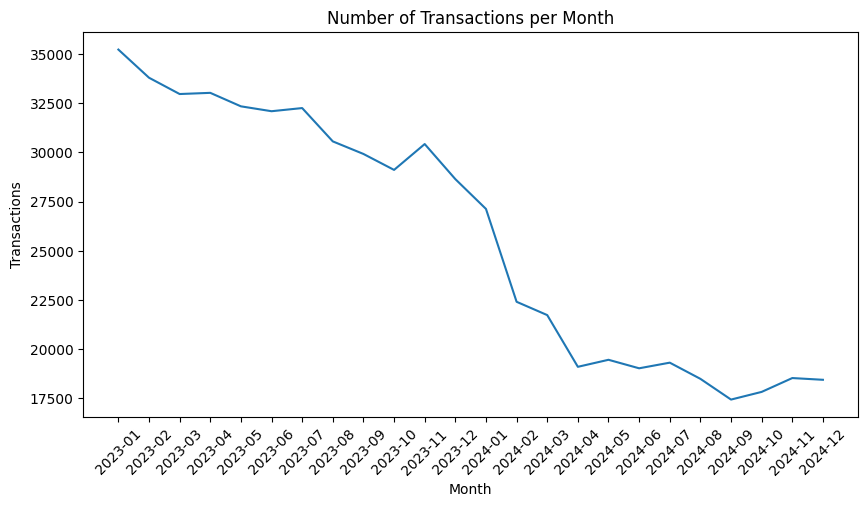

In [ ]:
plt.figure(figsize=(10,5))

monthly_sales = df.groupby(df["sales_date"].dt.to_period("M")).size()

monthly_sales.index = monthly_sales.index.astype(str)

sns.lineplot(x=monthly_sales.index, y=monthly_sales.values)

plt.xticks(rotation=45)
plt.title("Number of Transactions per Month")
plt.xlabel("Month")
plt.ylabel("Transactions")

plt.show()

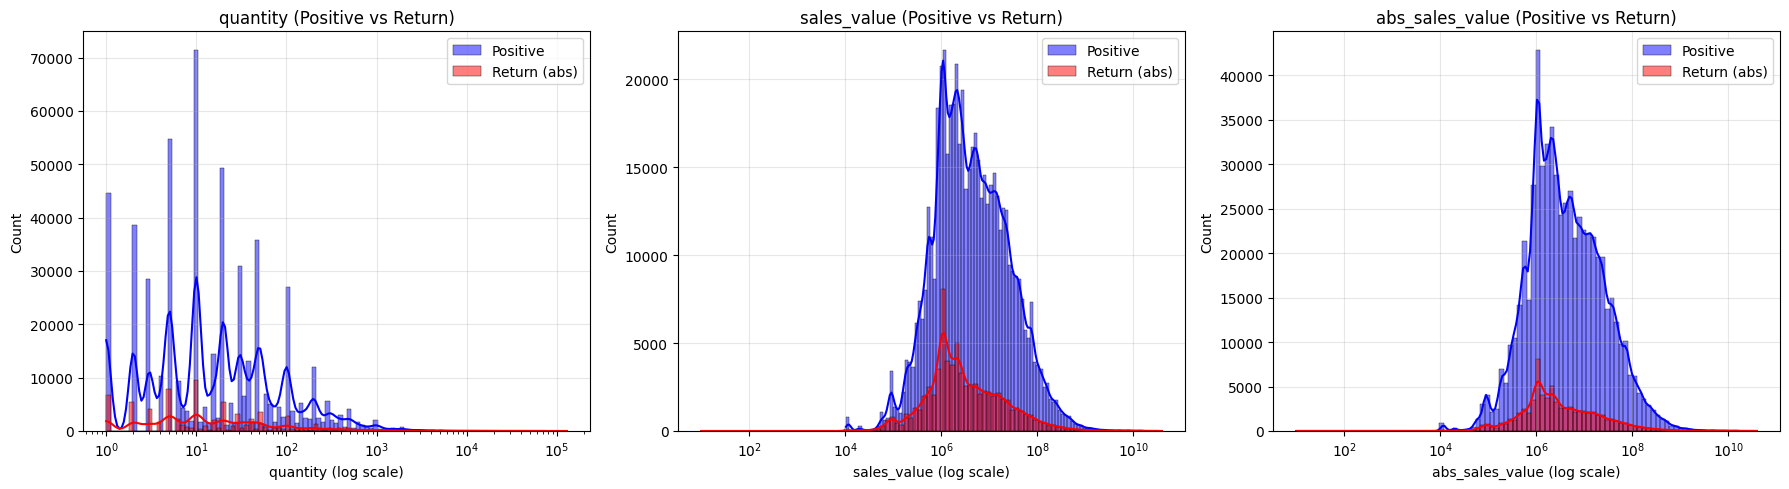

In [ ]:
# Histogram cho các numerical quan trọng (1 hàng ngang)
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(18, 5))  # chiều ngang dài hơn, chiều cao thấp lại

cols = ['quantity', 'sales_value', 'abs_sales_value']

for i, col in enumerate(cols, 1):
    plt.subplot(1, 3, i)  # <-- 1 hàng, 3 cột

    # Positive
    sns.histplot(
        df[df[col] > 0][col],
        bins=100,
        kde=True,
        color='blue',
        label='Positive',
        log_scale=(True, False)
    )

    # Return absolute
    if col == 'abs_sales_value':
        sns.histplot(
            df[df['sales_value'] < 0]['sales_value'].abs(),
            bins=100,
            kde=True,
            color='red',
            label='Return (abs)',
            log_scale=(True, False)
        )
    else:
        sns.histplot(
            df[df[col] < 0][col].abs(),
            bins=100,
            kde=True,
            color='red',
            label='Return (abs)',
            log_scale=(True, False)
        )

    plt.title(f'{col} (Positive vs Return)')
    plt.xlabel(col + ' (log scale)')
    plt.ylabel('Count')
    plt.legend()
    plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('eda_histograms_horizontal.png', dpi=300)
plt.show()

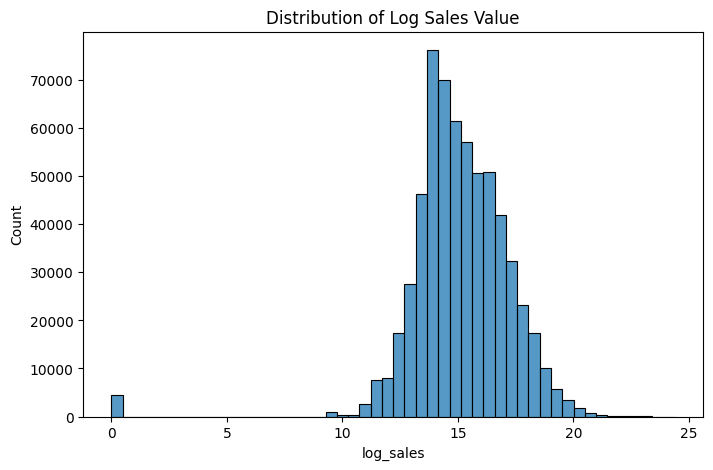

In [ ]:
df["log_sales"] = np.log1p(df["abs_sales_value"])

plt.figure(figsize=(8,5))
sns.histplot(df["log_sales"], bins=50)

plt.title("Distribution of Log Sales Value")
plt.show()

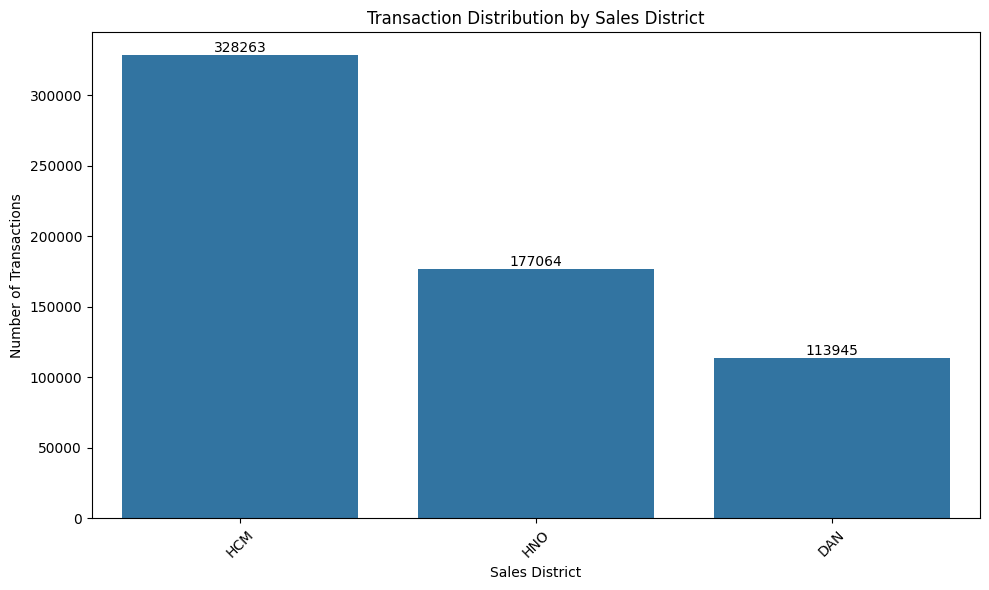

In [ ]:
district_counts = df["sales_district"].value_counts()

plt.figure(figsize=(10,6))

ax = sns.barplot(
    x=district_counts.index,
    y=district_counts.values
)

plt.title("Transaction Distribution by Sales District")
plt.xlabel("Sales District")
plt.ylabel("Number of Transactions")

# xoay label cho dễ đọc
plt.xticks(rotation=45)

# thêm label trên cột
for container in ax.containers:
    ax.bar_label(container, fmt='%d')

plt.tight_layout()
plt.show()

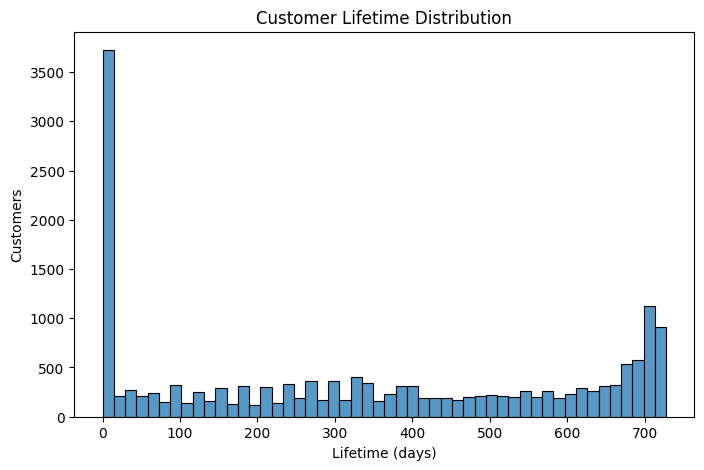

In [ ]:
customer_lifetime = (
    df.groupby("customer_code")["sales_date"]
    .agg(["min","max"])
)

customer_lifetime["lifetime_days"] = (
    customer_lifetime["max"] - customer_lifetime["min"]
).dt.days


plt.figure(figsize=(8,5))

sns.histplot(customer_lifetime["lifetime_days"], bins=50)

plt.title("Customer Lifetime Distribution")
plt.xlabel("Lifetime (days)")
plt.ylabel("Customers")

plt.show()

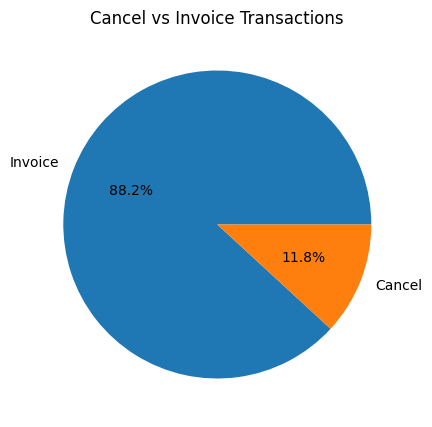

In [ ]:
cancel_counts = df["is_cancel"].value_counts()

plt.figure(figsize=(5,5))

plt.pie(
    cancel_counts,
    labels=["Invoice","Cancel"],
    autopct="%1.1f%%"
)

plt.title("Cancel vs Invoice Transactions")

plt.show()

**CHIA CỬA SỔ QUAN SÁT**

In [ ]:
PREDICTION_DAYS = 90
observation_end = df['sales_date'].max() - timedelta(days=PREDICTION_DAYS)
print(f"Observation window kết thúc: {observation_end.date()}")
print(f"Prediction window: {observation_end + timedelta(days=1)} đến {df['sales_date'].max().date()}")

# Chia dữ liệu
df_observation = df[df['sales_date'] <= observation_end].copy()
df_future = df[df['sales_date'] > observation_end].copy()
df_future_positive = df_future[df_future['sales_value'] > 0].copy()

print(f"Số giao dịch trong observation: {len(df_observation)}")
print(f"Số giao dịch trong prediction: {len(df_future)}")

Observation window kết thúc: 2024-10-02
Prediction window: 2024-10-03 00:00:00 đến 2024-12-31
Số giao dịch trong observation: 566193
Số giao dịch trong prediction: 53079


**FEATURE ENGINEERING**


In [ ]:
# 1. FREQUENCY
positive_invoices = (
    df_observation[df_observation['sales_value'] > 0]
    .groupby(['customer_code', 'invoice_number'])['sales_value']
    .sum()
    .reset_index()
)

customer_df = (
    positive_invoices
    .groupby('customer_code')['invoice_number']
    .nunique()
    .reset_index(name='frequency')
)

# 2. NET MONETARY
net_monetary = (
    df_observation
    .groupby('customer_code')['sales_value']
    .sum()
    .reset_index(name='net_monetary')
)

# 3. GROSS SALES
gross_sales = (
    df_observation[df_observation['sales_value'] > 0]
    .groupby('customer_code')['sales_value']
    .sum()
    .reset_index(name='gross_sales')
)

# 4. CANCEL FEATURES (chỉ merge gross_sales 1 lần)
cancel_abs_value = (
    df_observation[df_observation['is_cancel'] == 1]
    .groupby('customer_code')['abs_sales_value']
    .sum()
    .reset_index(name='abs_cancel_value')
)

cancel_transaction_rate = (
    df_observation
    .groupby('customer_code')['is_cancel']
    .mean()
    .reset_index(name='cancel_transaction_rate')
)

cancel_count = (
    df_observation
    .groupby('customer_code')['is_cancel']
    .sum()
    .reset_index(name='cancel_count')
)

# Merge và tính ratio
cancel_features = cancel_abs_value.merge(gross_sales, on='customer_code', how='left')
cancel_features['cancel_ratio'] = cancel_features['abs_cancel_value'] / (cancel_features['gross_sales'] + 1e-6)

cancel_features = cancel_features.merge(cancel_transaction_rate, on='customer_code', how='left')
cancel_features = cancel_features.merge(cancel_count, on='customer_code', how='left')

# 5. AVG BASKET VALUE
avg_basket_positive = (
    positive_invoices
    .groupby('customer_code')
    .agg(
        total_positive=('sales_value', 'sum'),
        num_invoices=('invoice_number', 'nunique')
    )
)
avg_basket_positive['avg_basket_value_positive'] = avg_basket_positive['total_positive'] / avg_basket_positive['num_invoices']
avg_basket_positive = avg_basket_positive[['avg_basket_value_positive']].reset_index()

# 6. PRODUCT DIVERSITY
product_diversity = (
    df_observation
    .groupby('customer_code')['item_code']
    .nunique()
    .reset_index(name='product_diversity')
)

# 7. TENURE DAYS
tenure_days = (
    df_observation
    .groupby('customer_code')['sales_date']
    .apply(lambda x: (x.max() - x.min()).days if len(x) > 1 else 0)
    .reset_index(name='tenure_days')
)

# 8. CREDIT ISSUE RATE
credit_issue_rate = (
    df_observation
    .groupby('customer_code')['has_credit_issue']
    .mean()
    .reset_index(name='credit_issue_rate')
)

# 9. MODE CATEGORICAL
categorical_cols_mode = [
    "order_source", "sales_district", "sales_type_code",
    "transaction_type", "ar_term", "warehouse_code"
]

mode_features = []
for col in categorical_cols_mode:
    mode_df = (
        df_observation
        .groupby('customer_code')[col]
        .agg(lambda x: x.mode().iloc[0] if not x.mode().empty else 'UNKNOWN')
        .reset_index(name=f'mode_{col}')
    )
    mode_features.append(mode_df)

**MERGE TẤT CẢ FEATURES VÀO CUSTOMER_DF**

In [ ]:
# ====================== MERGE ALL FEATURES - PHIÊN BẢN AN TOÀN ======================

# Trước tiên rename cột gross_sales trong cancel_features để tránh trùng
cancel_features = cancel_features.rename(columns={'gross_sales': 'gross_sales_from_cancel'})

# Bây giờ merge với thứ tự rõ ràng
features_to_merge = [
    net_monetary,
    gross_sales,                    # gross_sales chính thức
    cancel_features,
    avg_basket_positive,
    product_diversity,
    tenure_days,
    credit_issue_rate
] + mode_features

for f in features_to_merge:
    customer_df = customer_df.merge(f, on='customer_code', how='left')

# Xóa cột thừa (gross_sales_from_cancel) vì ta đã có gross_sales chính
if 'gross_sales_from_cancel' in customer_df.columns:
    customer_df = customer_df.drop(columns=['gross_sales_from_cancel'])

customer_df.fillna(0, inplace=True)

# === KIỂM TRA KẾT QUẢ ===
print(f"Số khách hàng: {customer_df.shape[0]:,}")
print(f"Số cột: {customer_df.shape[1]}")
print("\nColumns trong customer_df:")
print(customer_df.columns.tolist())

# Kiểm tra xem có cột 'gross_sales' không
print("\nCó cột 'gross_sales' không?", 'gross_sales' in customer_df.columns)
print("Các cột chứa 'gross':", [col for col in customer_df.columns if 'gross' in col.lower()])

Số khách hàng: 14,288
Số cột: 18

Columns trong customer_df:
['customer_code', 'frequency', 'net_monetary', 'gross_sales', 'abs_cancel_value', 'cancel_ratio', 'cancel_transaction_rate', 'cancel_count', 'avg_basket_value_positive', 'product_diversity', 'tenure_days', 'credit_issue_rate', 'mode_order_source', 'mode_sales_district', 'mode_sales_type_code', 'mode_transaction_type', 'mode_ar_term', 'mode_warehouse_code']

Có cột 'gross_sales' không? True
Các cột chứa 'gross': ['gross_sales']


**GẮN NHÃN REPEAT (DỰA VÀO PREDICTION WINDOW)**

In [ ]:
# Last positive purchase
last_positive = (
    df_observation[df_observation['sales_value'] > 0]
    .groupby('customer_code')['sales_date']
    .max()
    .reset_index(name='last_positive_purchase_in_obs')
)

# Has positive purchase before
has_positive_flag = (
    df_observation[df_observation['sales_value'] > 0]
    .groupby('customer_code')
    .size()
    .reset_index(name='positive_txn_cnt_in_obs')
)
has_positive_flag['has_positive_purchase_before'] = 1

# All customers in observation
all_customers = pd.DataFrame({'customer_code': df_observation['customer_code'].unique()})

label_base = all_customers.merge(last_positive, on='customer_code', how='left')
label_base = label_base.merge(
    has_positive_flag[['customer_code', 'has_positive_purchase_before']],
    on='customer_code', how='left'
)
label_base['has_positive_purchase_before'] = label_base['has_positive_purchase_before'].fillna(0).astype(int)

# Recency
label_base['recency'] = pd.NA
mask = label_base['has_positive_purchase_before'] == 1
label_base.loc[mask, 'recency'] = (
    observation_end - label_base.loc[mask, 'last_positive_purchase_in_obs']
).dt.days
label_base.loc[~mask, 'recency'] = 9999
label_base['recency'] = label_base['recency'].astype(int)

# Future positive orders
future_order_cnt = (
    df_future_positive
    .groupby('customer_code')
    .size()
    .reset_index(name='future_positive_orders')
)

label_base = label_base.merge(future_order_cnt, on='customer_code', how='left')
label_base['future_positive_orders'] = label_base['future_positive_orders'].fillna(0).astype(int)

# Target: repeat = 1 nếu ≥ 1 đơn dương trong prediction window
label_base['repeat'] = (label_base['future_positive_orders'] > 1).astype(int)

# Merge label vào customer_df
customer_df = customer_df.merge(
    label_base[['customer_code', 'repeat', 'recency', 'has_positive_purchase_before']],
    on='customer_code', how='left'
)

# Xử lý khách mới / không có dữ liệu
customer_df['repeat'] = customer_df['repeat'].fillna(0).astype(int)
customer_df['recency'] = customer_df['recency'].fillna(9999).astype(int)
customer_df['has_positive_purchase_before'] = customer_df['has_positive_purchase_before'].fillna(0).astype(int)

print(f"Số khách repeat (≥1 đơn): {customer_df['repeat'].sum():,}")
print(f"Tỷ lệ repeat: {customer_df['repeat'].mean():.2%}")

Số khách repeat (≥1 đơn): 2,889
Tỷ lệ repeat: 20.22%


**TRAIN MÔ HÌNH**

In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, classification_report

**CHIA CLIENT**

In [ ]:
client_column = 'mode_sales_district'
clients = customer_df[client_column].unique()

client_train = defaultdict(pd.DataFrame)
client_test = defaultdict(pd.DataFrame)

for client_id in clients:
    sub_df = customer_df[customer_df[client_column] == client_id].copy()
    if len(sub_df) < 50:
        continue
    train_df, test_df = train_test_split(
        sub_df, test_size=0.2, random_state=42, stratify=sub_df['repeat']
    )
    client_train[client_id] = train_df
    client_test[client_id] = test_df

global_test = pd.concat(client_test.values(), ignore_index=True)

In [ ]:

from collections import defaultdict

In [ ]:


cat_cols = [
    "mode_order_source",
    "mode_sales_district",
    "mode_sales_type_code",
    "mode_transaction_type",
    "mode_ar_term",
    "mode_warehouse_code"
]

numerical_cols = [
    'frequency', 'net_monetary', 'gross_sales', 'abs_cancel_value',
    'cancel_ratio', 'cancel_transaction_rate', 'cancel_count',
    'avg_basket_value_positive', 'product_diversity', 'tenure_days',
    'credit_issue_rate', 'recency', 'has_positive_purchase_before'
]

print(f"\nNumerical columns ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical columns ({len(cat_cols)}): {cat_cols}")

# 2. Preprocessing: Scale numerical + OneHot categorical (fit trên toàn train để chung vocabulary)
all_train_df = pd.concat(client_train.values(), ignore_index=True)

scaler = StandardScaler()
all_train_df[numerical_cols] = scaler.fit_transform(all_train_df[numerical_cols])

encoders = {}
for col in cat_cols:
    encoder = OneHotEncoder(sparse_output=False, handle_unknown='ignore')
    encoder.fit(all_train_df[[col]])
    encoders[col] = encoder

# 3. Áp dụng preprocess cho từng client → chuyển thành numpy
clients_data = {}
for client, train_df in client_train.items():
    test_df = client_test[client]

    train_proc = train_df.copy()
    test_proc = test_df.copy()

    # Scale numerical
    train_proc[numerical_cols] = scaler.transform(train_proc[numerical_cols])
    test_proc[numerical_cols] = scaler.transform(test_proc[numerical_cols])

    # Numerical part
    X_train_num = train_proc[numerical_cols].values.astype(np.float32)
    X_test_num = test_proc[numerical_cols].values.astype(np.float32)

    # Categorical part (OneHot)
    if cat_cols:
        X_train_cat = np.hstack([encoders[col].transform(train_proc[[col]]) for col in cat_cols]).astype(np.float32)
        X_test_cat = np.hstack([encoders[col].transform(test_proc[[col]]) for col in cat_cols]).astype(np.float32)
    else:
        X_train_cat = np.empty((len(train_proc), 0), dtype=np.float32)
        X_test_cat = np.empty((len(test_proc), 0), dtype=np.float32)

    X_train = np.hstack([X_train_num, X_train_cat])
    X_test = np.hstack([X_test_num, X_test_cat])

    y_train = train_proc['repeat'].values.astype(np.float32)
    y_test = test_proc['repeat'].values.astype(np.float32)

    clients_data[client] = {
        'X_train': X_train, 'y_train': y_train,
        'X_test': X_test, 'y_test': y_test,
        'size': len(y_train)
    }




Numerical columns (13): ['frequency', 'net_monetary', 'gross_sales', 'abs_cancel_value', 'cancel_ratio', 'cancel_transaction_rate', 'cancel_count', 'avg_basket_value_positive', 'product_diversity', 'tenure_days', 'credit_issue_rate', 'recency', 'has_positive_purchase_before']
Categorical columns (6): ['mode_order_source', 'mode_sales_district', 'mode_sales_type_code', 'mode_transaction_type', 'mode_ar_term', 'mode_warehouse_code']


In [ ]:
num_features = len(numerical_cols)
cat_features = sum(
    encoders[col].categories_[0].shape[0] for col in cat_cols
)

print("Numerical features:", num_features)
print("Categorical (OneHot) features:", cat_features)


Numerical features: 13
Categorical (OneHot) features: 56


In [ ]:
print("Total feature dimension:", X_train.shape[1])
for client, data in clients_data.items():
    print(client, data["X_train"].shape)

Total feature dimension: 69
HCM (7324, 69)
DAN (1322, 69)
HNO (2784, 69)


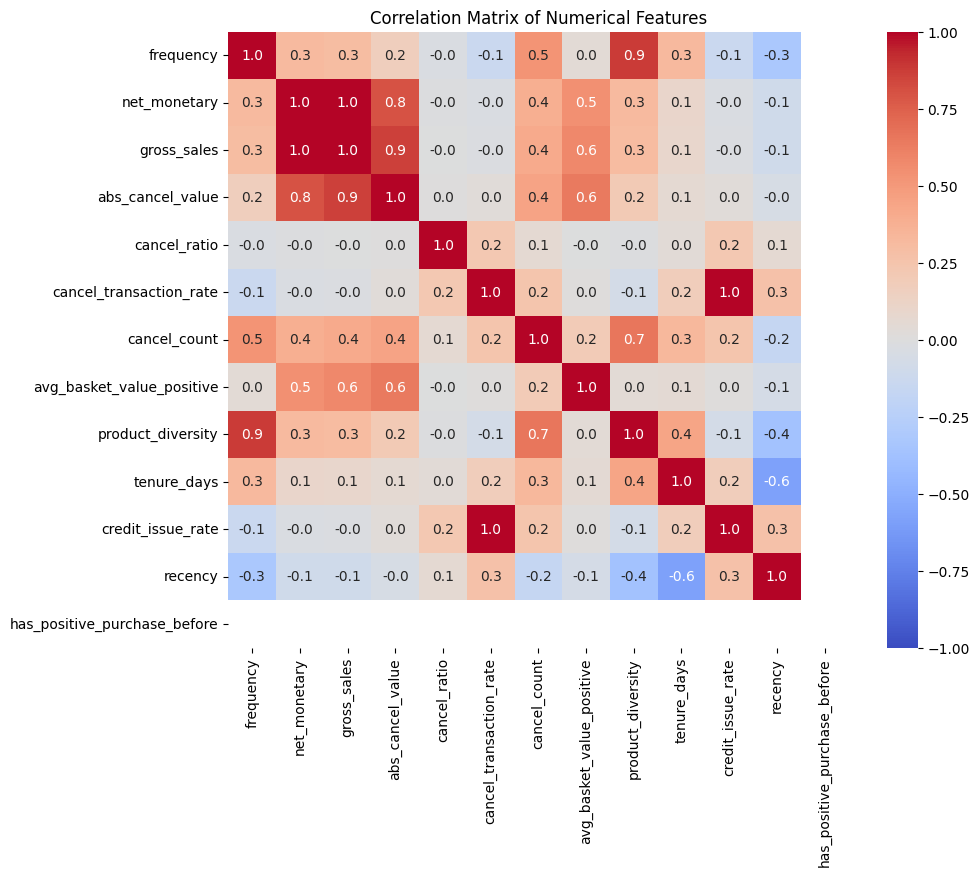

In [ ]:
plt.figure(figsize=(10,8))

corr = customer_df[numerical_cols].corr()

sns.heatmap(corr, annot=True, cmap='coolwarm', vmin=-1, vmax=1, fmt='.1f')

plt.title("Correlation Matrix of Numerical Features")

plt.show()

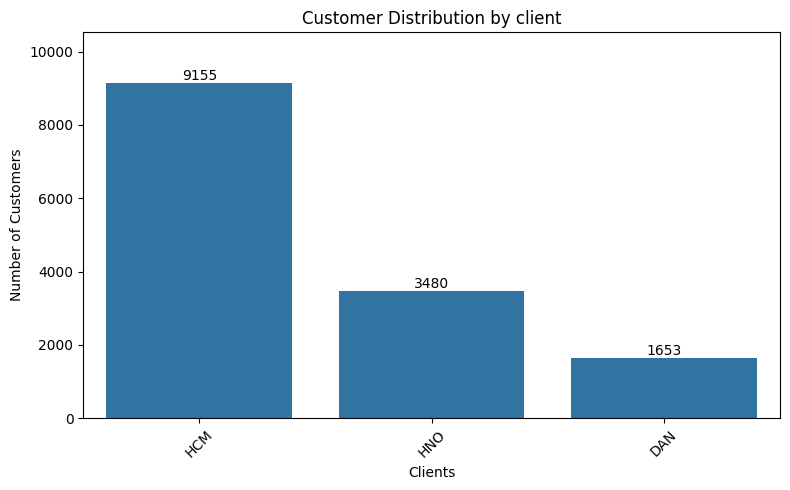

In [ ]:
district_counts = customer_df["mode_sales_district"].value_counts() #CHỨNG MINH data imbalance giữa clients

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=district_counts.index,
    y=district_counts.values
)

plt.title("Customer Distribution by client")
plt.xlabel("Clients")
plt.ylabel("Number of Customers")

plt.xticks(rotation=45)

# thêm label trên cột
for container in ax.containers:
    ax.bar_label(container)

# tạo khoảng trống phía trên
ax.set_ylim(0, district_counts.max() * 1.15)

plt.tight_layout()
plt.show()

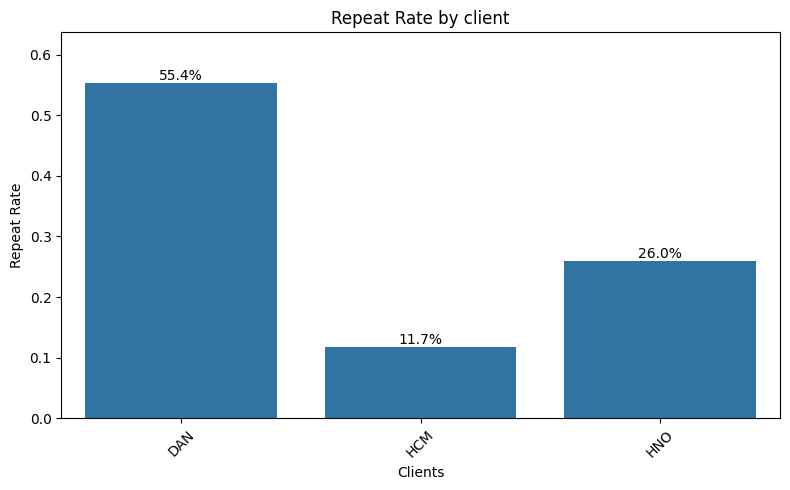

In [ ]:
#cHỨNG MINH DỮ LIỆU non-IID
repeat_rate = (
    customer_df
    .groupby("mode_sales_district")["repeat"]
    .mean()
)

plt.figure(figsize=(8,5))

ax = sns.barplot(
    x=repeat_rate.index,
    y=repeat_rate.values
)

plt.title("Repeat Rate by client")
plt.xlabel("Clients")
plt.ylabel("Repeat Rate")

plt.xticks(rotation=45)

# thêm label %
for container in ax.containers:
    labels = [f"{v:.1%}" for v in container.datavalues]
    ax.bar_label(container, labels=labels)

# tạo khoảng trống phía trên
ax.set_ylim(0, repeat_rate.max() * 1.15)

plt.tight_layout()
plt.show()

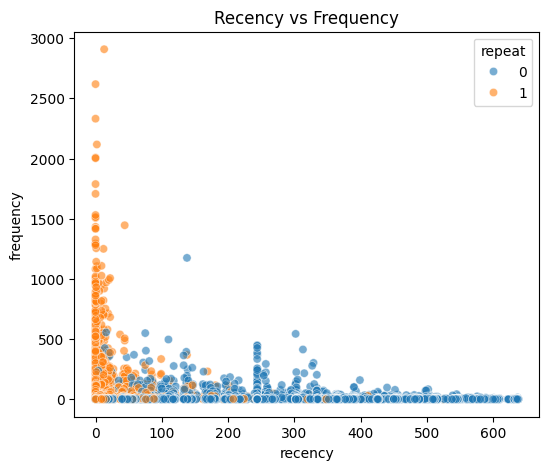

In [ ]:
#customer behavior clusters
plt.figure(figsize=(6,5))

sns.scatterplot(
    data=customer_df,
    x="recency",
    y="frequency",
    hue="repeat",
    alpha=0.6
)

plt.title("Recency vs Frequency")

plt.show()

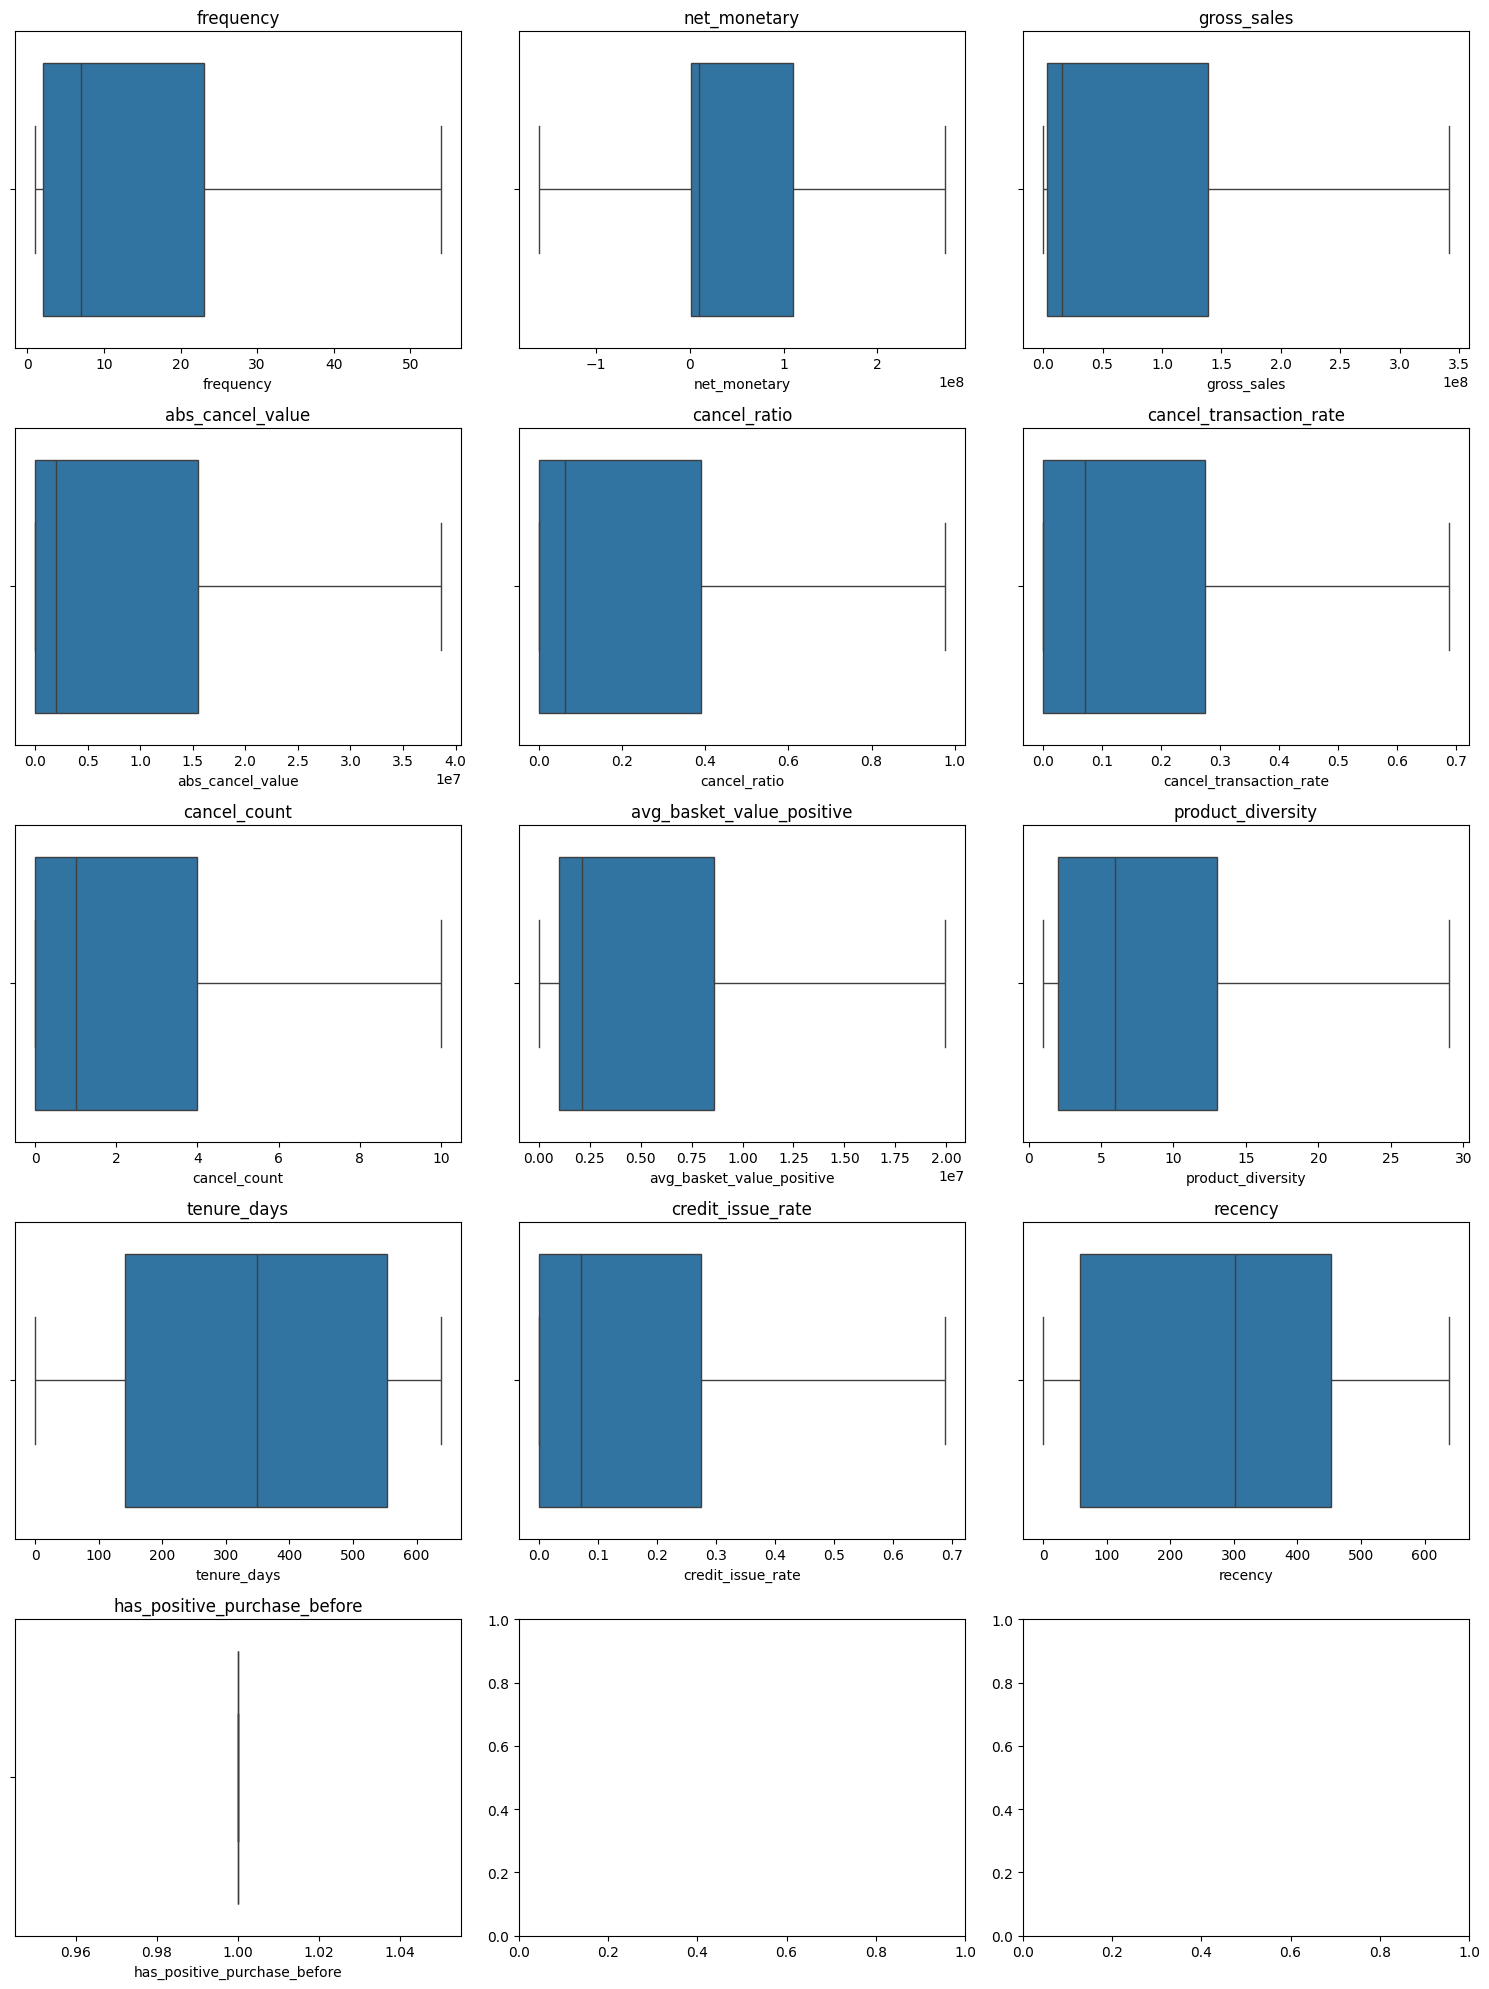

In [ ]:
rows = 5
cols = 3

fig, axes = plt.subplots(rows, cols, figsize=(5*cols, 4*rows))

axes = axes.flatten()

for i, col in enumerate(numerical_cols):
    sns.boxplot(x=customer_df[col], ax=axes[i], showfliers=False)
    axes[i].set_title(col)

plt.tight_layout()
plt.show()

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

# Lưu tỷ lệ repeat
train_ratios = {}
test_ratios = {}

for client_id in client_train.keys():
    train_df = client_train[client_id]
    test_df = client_test[client_id]

    # Tỷ lệ repeat
    train_ratios[client_id] = train_df['repeat'].mean()
    test_ratios[client_id] = test_df['repeat'].mean()

train_ratios = pd.Series(train_ratios)
test_ratios = pd.Series(test_ratios)

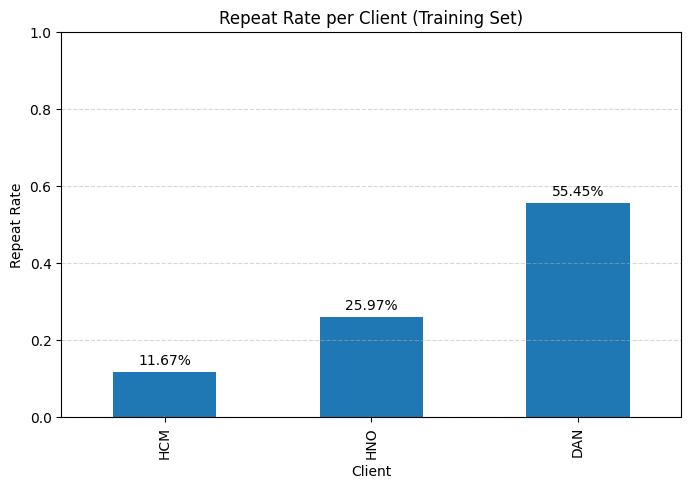

In [ ]:
plt.figure(figsize=(8,5))

train_ratios.sort_values().plot(kind='bar')

plt.title("Repeat Rate per Client (Training Set)")
plt.ylabel("Repeat Rate")
plt.xlabel("Client")
plt.ylim(0,1)
plt.grid(axis='y', linestyle='--', alpha=0.5)

for i, v in enumerate(train_ratios.sort_values()):
    plt.text(i, v + 0.02, f"{v:.2%}", ha='center')

plt.show()

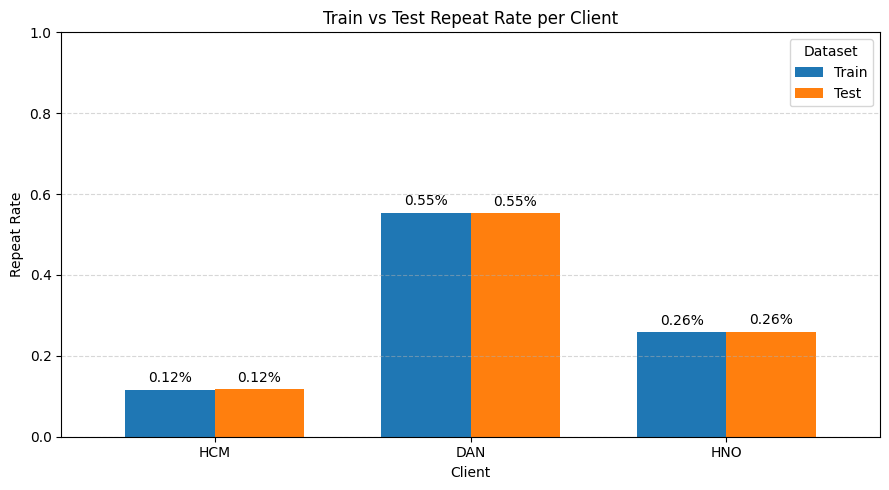

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

df_compare = pd.DataFrame({
    'Train': train_ratios,
    'Test': test_ratios
})

ax = df_compare.plot(kind='bar', figsize=(9,5), width=0.7)

plt.title("Train vs Test Repeat Rate per Client")
plt.ylabel("Repeat Rate")
plt.xlabel("Client")
plt.ylim(0, 1)
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.xticks(rotation=0)

# 👉 Lấy container của từng nhóm bar và add label chuẩn vị trí
for container in ax.containers:
    ax.bar_label(container, fmt='%.2f%%', padding=3)

plt.legend(title="Dataset")
plt.tight_layout()
plt.show()

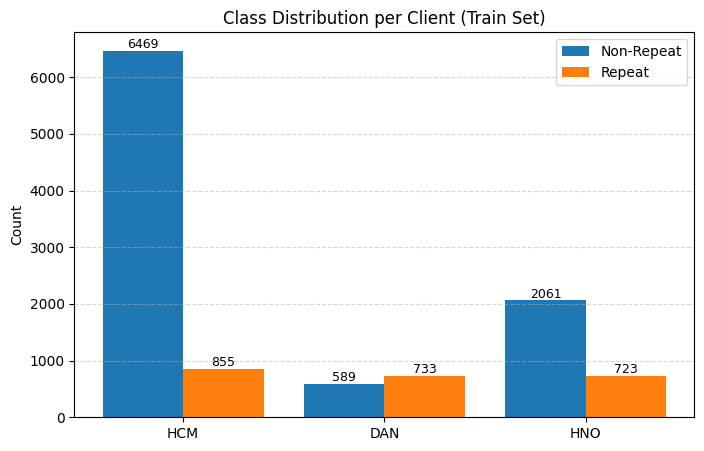

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

labels = []
non_repeat = []
repeat = []

for client_id in client_train.keys():
    df = client_train[client_id]

    labels.append(client_id)
    non_repeat.append((df['repeat'] == 0).sum())
    repeat.append((df['repeat'] == 1).sum())

x = np.arange(len(labels))

plt.figure(figsize=(8,5))

bars1 = plt.bar(x - 0.2, non_repeat, width=0.4, label='Non-Repeat')
bars2 = plt.bar(x + 0.2, repeat, width=0.4, label='Repeat')

# 👉 Thêm label trên từng cột
for bar in bars1:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

for bar in bars2:
    height = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, height,
             f'{int(height)}',
             ha='center', va='bottom', fontsize=9)

plt.xticks(x, labels)
plt.title("Class Distribution per Client (Train Set)")
plt.ylabel("Count")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.5)

plt.show()

Số khách hàng: 14,288
Số features numerical: 10
Số features categorical: 6

Danh sách numerical features sau tối ưu:
['frequency', 'gross_sales', 'avg_basket_value_positive', 'cancel_ratio', 'cancel_transaction_rate', 'cancel_count', 'tenure_days', 'credit_issue_rate', 'recency', 'has_positive_purchase_before']

Columns cuối cùng:
['customer_code', 'frequency', 'gross_sales', 'avg_basket_value_positive', 'cancel_ratio', 'cancel_transaction_rate', 'cancel_count', 'tenure_days', 'credit_issue_rate', 'recency', 'has_positive_purchase_before', 'mode_order_source', 'mode_sales_district', 'mode_sales_type_code', 'mode_transaction_type', 'mode_ar_term', 'mode_warehouse_code', 'repeat']

🔍 Correlation sau khi giảm feature:


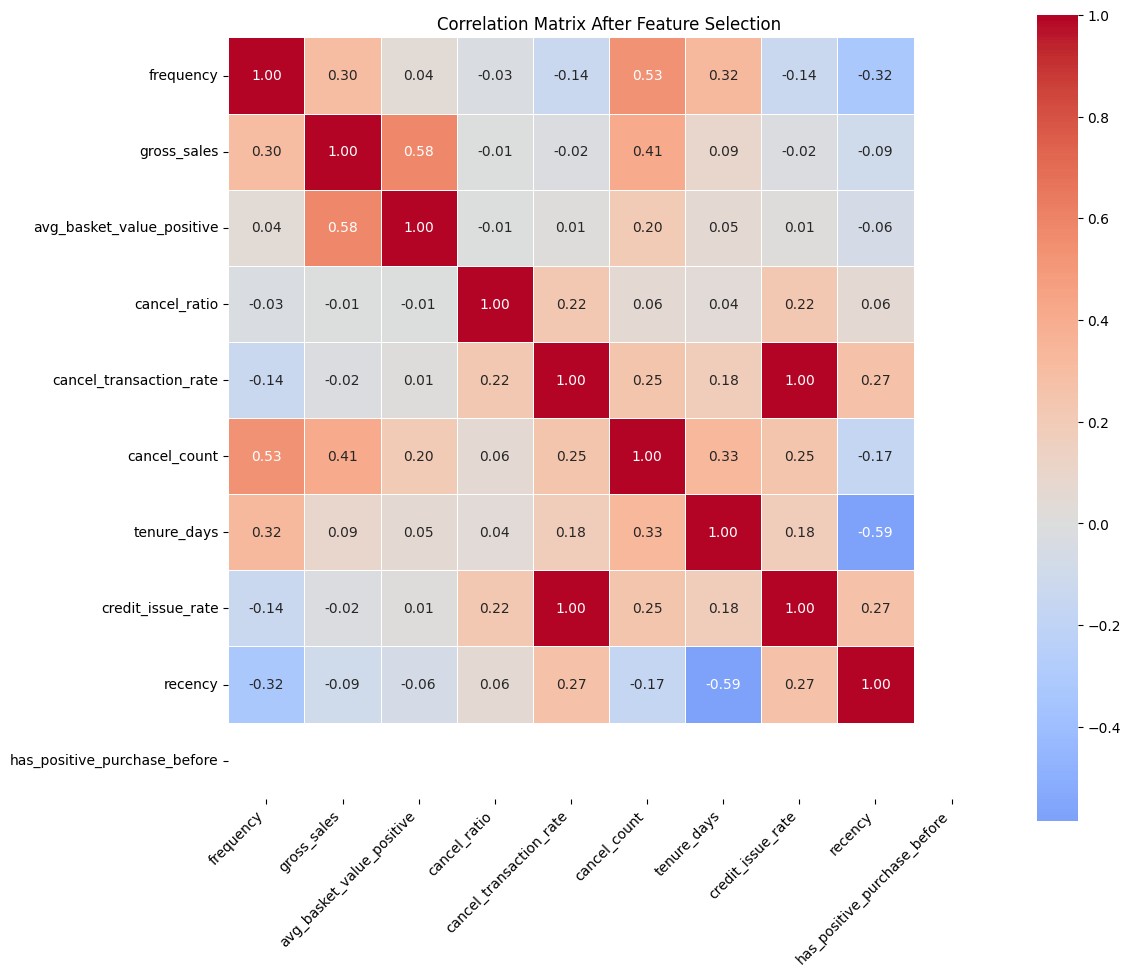

Numerical cols (10): ['frequency', 'gross_sales', 'avg_basket_value_positive', 'cancel_ratio', 'cancel_transaction_rate', 'cancel_count', 'tenure_days', 'credit_issue_rate', 'recency', 'has_positive_purchase_before']
Categorical cols (6): ['mode_order_source', 'mode_sales_district', 'mode_sales_type_code', 'mode_transaction_type', 'mode_ar_term', 'mode_warehouse_code']


In [ ]:
# ====================== TỰ ĐỘNG DỌN DẸP & CHỌN FEATURE TỐI ƯU ======================

# Danh sách các cột chúng ta muốn giữ (phiên bản tối ưu)
optimal_numerical = [
    'frequency',                    # Giữ frequency thay vì product_diversity
    'gross_sales',                  # Giữ gross sales (bỏ net_monetary vì tương quan 1.0)
    'avg_basket_value_positive',
    'cancel_ratio',                 # Feature độc lập tốt
    'cancel_transaction_rate',
    'cancel_count',
    'tenure_days',
    'credit_issue_rate',
    'recency',
    'has_positive_purchase_before'
]

optimal_categorical = [
    "mode_order_source",
    "mode_sales_district",
    "mode_sales_type_code",
    "mode_transaction_type",
    "mode_ar_term",
    "mode_warehouse_code"
]

# ====================== DỌN DẸP CUSTOMER_DF ======================


# Tạo bản sao để tránh ảnh hưởng dữ liệu cũ
df_clean = customer_df.copy()

# Xử lý các cột có suffix _x, _y (nếu còn)
for col in optimal_numerical + optimal_categorical:
    if col + '_x' in df_clean.columns:
        df_clean = df_clean.rename(columns={col + '_x': col})
    if col + '_y' in df_clean.columns:
        df_clean = df_clean.rename(columns={col + '_y': col})

# Giữ lại đúng các cột cần thiết
all_keep_cols = ['customer_code'] + optimal_numerical + optimal_categorical + ['repeat']

# Chỉ giữ những cột thực sự tồn tại
existing_cols = [col for col in all_keep_cols if col in df_clean.columns]

df_clean = df_clean[existing_cols].copy()

# Fillna lần cuối
df_clean.fillna(0, inplace=True)

# Cập nhật lại customer_df
customer_df = df_clean


print(f"Số khách hàng: {customer_df.shape[0]:,}")
print(f"Số features numerical: {len(optimal_numerical)}")
print(f"Số features categorical: {len(optimal_categorical)}")
print("\nDanh sách numerical features sau tối ưu:")
print(optimal_numerical)
print("\nColumns cuối cùng:")
print(customer_df.columns.tolist())

# ====================== KIỂM TRA TƯƠNG QUAN SAU KHI GIẢM ======================
print("\n🔍 Correlation sau khi giảm feature:")

numerical_for_corr = [col for col in optimal_numerical if col in customer_df.columns]

corr_matrix = customer_df[numerical_for_corr].corr()

# Vẽ lại correlation matrix để kiểm tra
plt.figure(figsize=(12, 10))
sns.heatmap(corr_matrix, annot=True, cmap='coolwarm', center=0, fmt='.2f',
            square=True, linewidths=0.5)
plt.title('Correlation Matrix After Feature Selection')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

# ====================== CẬP NHẬT numerical_cols & cat_cols ======================
numerical_cols = optimal_numerical
cat_cols = optimal_categorical


print(f"Numerical cols ({len(numerical_cols)}): {numerical_cols}")
print(f"Categorical cols ({len(cat_cols)}): {cat_cols}")

In [ ]:
from sklearn.metrics import (
    accuracy_score, precision_score, recall_score, f1_score,
    roc_auc_score, precision_recall_curve, classification_report,
    confusion_matrix, roc_curve, auc
)

In [ ]:
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.nn.utils import clip_grad_norm_
from torch.utils.data import DataLoader, TensorDataset
from sklearn.metrics import (accuracy_score, precision_score, recall_score,
                             f1_score, confusion_matrix, roc_curve, auc)
import matplotlib.pyplot as plt
import seaborn as sns
import random
import warnings

warnings.filterwarnings('ignore')

# ====================== RANDOM SEED ======================
def set_seed(seed=42):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed(seed)
        torch.cuda.manual_seed_all(seed)
        torch.backends.cudnn.deterministic = True
        torch.backends.cudnn.benchmark = False
    print(f"✅ Random seed đã được thiết lập: {seed}")

set_seed(42)
# ========================================================

# ──────────────────────────────────────────────────────────────
# 1. Mô hình MLP
# ──────────────────────────────────────────────────────────────
class RetentionMLP(nn.Module):
    def __init__(self, input_size):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_size, 64),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(64, 32),
            nn.ReLU(),
            nn.Dropout(0.2),

            nn.Linear(32, 1)
        )

    def forward(self, x):
        return self.net(x)


# ──────────────────────────────────────────────────────────────
# 2. Train local (Phiên bản 1 - KHÔNG class weight)
# ──────────────────────────────────────────────────────────────
def train_local_fedprox(model, global_state, X_train, y_train,
                        mu=0.1, local_epochs=120, batch_size=64, lr=8e-5, seed=42):

    model.load_state_dict(global_state)
    optimizer = optim.Adam(model.parameters(), lr=lr)
    criterion = nn.BCEWithLogitsLoss()          # ← Không dùng pos_weight

    dataset = TensorDataset(
        torch.tensor(X_train, dtype=torch.float32),
        torch.tensor(y_train, dtype=torch.float32).unsqueeze(1)
    )
    g = torch.Generator()
    g.manual_seed(seed)
    loader = DataLoader(dataset, batch_size=batch_size, shuffle=True, generator=g)

    epoch_losses = []
    for epoch in range(local_epochs):
        batch_losses = []
        for bx, by in loader:
            optimizer.zero_grad()
            output = model(bx)

            loss = criterion(output, by)

            # Proximal term
            prox_term = 0.0
            for p_local, p_global in zip(model.parameters(), global_state.values()):
                prox_term += torch.sum((p_local - p_global) ** 2)

            loss = loss + (mu / 2.0) * prox_term

            loss.backward()
            clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()

            batch_losses.append(loss.item())

        mean_epoch_loss = np.mean(batch_losses) if batch_losses else 0.0
        epoch_losses.append(mean_epoch_loss)

    return model, epoch_losses


# ──────────────────────────────────────────────────────────────
# 3. Aggregation
# ──────────────────────────────────────────────────────────────
def fedprox_aggregate(local_models_list, client_sizes_list):
    total_size = sum(client_sizes_list)
    input_size = clients_data[list(clients_data.keys())[0]]['X_train'].shape[1]

    global_model = RetentionMLP(input_size)
    global_dict = global_model.state_dict()

    for key in global_dict.keys():
        global_dict[key] = sum(
            model.state_dict()[key] * (size / total_size)
            for model, size in zip(local_models_list, client_sizes_list)
        )

    global_model.load_state_dict(global_dict)
    return global_model


# ──────────────────────────────────────────────────────────────
# 4. Evaluate
# ──────────────────────────────────────────────────────────────
def evaluate_model(model, X_test_all, y_test_all):

    model.eval()

    with torch.no_grad():
        logits = model(torch.tensor(X_test_all, dtype=torch.float32)).squeeze()
        y_pred_proba = torch.sigmoid(logits).numpy()

    # =============================
    # Tìm threshold tốt nhất
    # =============================

    thresholds = np.arange(0.3, 0.6, 0.01)

    best_f1 = 0
    best_threshold = 0.5

    for t in thresholds:

        preds = (y_pred_proba >= t).astype(int)

        f1 = f1_score(y_test_all, preds)

        if f1 > best_f1:
            best_f1 = f1
            best_threshold = t

    print(f"\nBest threshold found: {best_threshold:.2f}")

    y_pred = (y_pred_proba >= best_threshold).astype(int)

    metrics = {
        'Accuracy': accuracy_score(y_test_all, y_pred),
        'Precision': precision_score(y_test_all, y_pred, zero_division=0),
        'Recall': recall_score(y_test_all, y_pred, zero_division=0),
        'F1-Score': f1_score(y_test_all, y_pred, zero_division=0)
    }

    return metrics, y_pred_proba, y_pred


# ──────────────────────────────────────────────────────────────
# 5. TRAINING - PHIÊN BẢN 1 (Adaptive LR + Không class weight)
# ──────────────────────────────────────────────────────────────

client_keys = list(clients_data.keys())
input_size = clients_data[client_keys[0]]['X_train'].shape[1]

X_global_test = np.vstack([clients_data[ck]['X_test'] for ck in client_keys])
y_global_test = np.concatenate([clients_data[ck]['y_test'] for ck in client_keys])

print(f"Input size: {input_size}")
print(f"Global test: {X_global_test.shape[0]} mẫu, positive rate: {np.mean(y_global_test):.2%}")

# ====================== THAM SỐ PHIÊN BẢN 1 ======================
num_rounds = 60

base_epochs = 60
min_epochs = 10

batch_size = 16
mu = 0.09          # Giảm mạnh
base_lr = 1.1e-4
alpha = 0.20       # Adaptive LR nhẹ hơn

client_sizes = {ck: clients_data[ck]['size'] for ck in client_keys}
median_size = np.median(list(client_sizes.values()))

# Adaptive Learning Rate
# ====================== Adaptive Learning Rate (Improved) ======================

base_lr = 1e-4
beta = 0.6     # imbalance sensitivity
gamma = 0.5    # size sensitivity

lr_dict = {}

print("\n=== Improved Adaptive Learning Rate ===")

for ck in client_keys:

    size = clients_data[ck]['size']
    y_train = clients_data[ck]['y_train']

    pos_ratio = y_train.mean()

    # ---------- SIZE FACTOR ----------
    size_factor = (size / median_size) ** gamma

    # ---------- IMBALANCE FACTOR ----------
    imbalance_factor = 1 + beta * (0.5 - pos_ratio)

    # ---------- LR ----------
    lr_client = base_lr * size_factor * imbalance_factor

    # ---------- CLIP ----------
    lr_client = np.clip(lr_client, 5e-5, 2e-4)

    lr_dict[ck] = lr_client

    print(
        f"Client {ck:>3} | "
        f"size={size:>5} | "
        f"pos_ratio={pos_ratio:.3f} | "
        f"lr={lr_client:.2e}"
    )

# Lưu lịch sử loss
client_loss_history = {ck: [] for ck in client_keys}
global_loss_history = []

global_model = RetentionMLP(input_size)

print(f"\n=== FedProx Phiên bản 1 (No Class Weight + Adaptive LR) - {num_rounds} rounds ===")

for round_num in range(1, num_rounds + 1):
    print(f"\n--- Round {round_num}/{num_rounds} ---")
    local_models_list = []
    round_client_losses = []

    for ck in client_keys:
        size = clients_data[ck]['size']
        y_train = clients_data[ck]['y_train']

        scale = (size / median_size) ** 0.3
        local_epochs = max(min_epochs, int(base_epochs * scale))

        local_model = RetentionMLP(input_size)

        local_model, epoch_losses = train_local_fedprox(
            local_model,
            global_model.state_dict(),
            clients_data[ck]['X_train'],
            y_train,
            mu=mu,
            local_epochs=local_epochs,
            batch_size=batch_size,
            lr=lr_dict[ck],
            seed=42 + round_num
        )

        local_models_list.append(local_model)
        mean_loss = np.mean(epoch_losses) if epoch_losses else 0.0
        round_client_losses.append(mean_loss)
        client_loss_history[ck].append(mean_loss)

        print(f"  Client {ck:>3} | size={size:>5} | epochs={local_epochs:>3} | "
              f"lr={lr_dict[ck]:.2e} | loss={mean_loss:.5f}")

    global_model = fedprox_aggregate(local_models_list, [clients_data[ck]['size'] for ck in client_keys])
    avg_loss = np.mean(round_client_losses)
    global_loss_history.append(avg_loss)
    print(f"Round {round_num} - Global Avg loss: {avg_loss:.4f}")

✅ Random seed đã được thiết lập: 42
Input size: 69
Global test: 2858 mẫu, positive rate: 20.22%

=== Improved Adaptive Learning Rate ===
Client HCM | size= 7324 | pos_ratio=0.117 | lr=1.99e-04
Client DAN | size= 1322 | pos_ratio=0.554 | lr=6.67e-05
Client HNO | size= 2784 | pos_ratio=0.260 | lr=1.14e-04

=== FedProx Phiên bản 1 (No Class Weight + Adaptive LR) - 60 rounds ===

--- Round 1/60 ---
  Client HCM | size= 7324 | epochs= 80 | lr=1.99e-04 | loss=0.31078
  Client DAN | size= 1322 | epochs= 47 | lr=6.67e-05 | loss=0.57006
  Client HNO | size= 2784 | epochs= 60 | lr=1.14e-04 | loss=0.42402
Round 1 - Global Avg loss: 0.4350

--- Round 2/60 ---
  Client HCM | size= 7324 | epochs= 80 | lr=1.99e-04 | loss=0.16266
  Client DAN | size= 1322 | epochs= 47 | lr=6.67e-05 | loss=0.41274
  Client HNO | size= 2784 | epochs= 60 | lr=1.14e-04 | loss=0.28361
Round 2 - Global Avg loss: 0.2863

--- Round 3/60 ---
  Client HCM | size= 7324 | epochs= 80 | lr=1.99e-04 | loss=0.13482
  Client DAN | siz

In [ ]:
metrics, y_pred_proba, y_pred = evaluate_model(
    global_model,
    X_global_test,
    y_global_test
)

print("\n===== GLOBAL MODEL PERFORMANCE =====")
for k,v in metrics.items():
    print(f"{k}: {v:.4f}")


Best threshold found: 0.39

===== GLOBAL MODEL PERFORMANCE =====
Accuracy: 0.9318
Precision: 0.8016
Recall: 0.8806
F1-Score: 0.8392


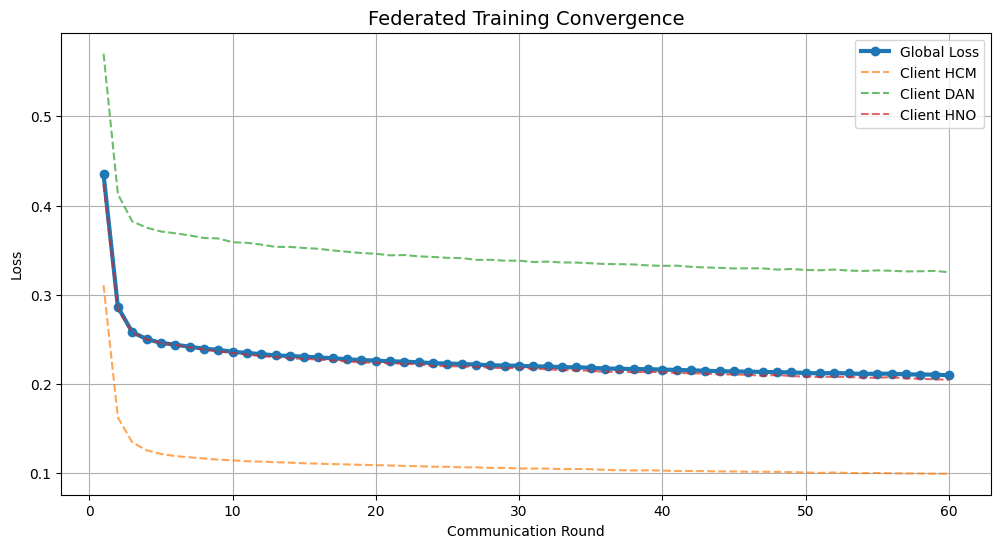

In [ ]:
# ========================================================
# VISUALIZE LOSS CONVERGENCE
# ========================================================

plt.figure(figsize=(12,6))

rounds = range(1, len(global_loss_history)+1)

plt.plot(rounds, global_loss_history,
         marker='o',
         linewidth=3,
         label="Global Loss")

for ck in client_loss_history.keys():
    plt.plot(rounds,
             client_loss_history[ck],
             linestyle="--",
             alpha=0.7,
             label=f"Client {ck}")

plt.title("Federated Training Convergence", fontsize=14)
plt.xlabel("Communication Round")
plt.ylabel("Loss")
plt.legend()
plt.grid(True)

plt.show()

In [ ]:
from sklearn.metrics import classification_report
print("\n" + "-"*70)
print("CHI TIẾT FEDERATED MODEL")
print("-"*70)
print(classification_report(y_global_test, y_pred, target_names=['Non-Repeat (0)', 'Repeat (1)'], digits=4))


----------------------------------------------------------------------
CHI TIẾT FEDERATED MODEL
----------------------------------------------------------------------
                precision    recall  f1-score   support

Non-Repeat (0)     0.9690    0.9447    0.9567      2280
    Repeat (1)     0.8016    0.8806    0.8392       578

      accuracy                         0.9318      2858
     macro avg     0.8853    0.9127    0.8980      2858
  weighted avg     0.9351    0.9318    0.9329      2858



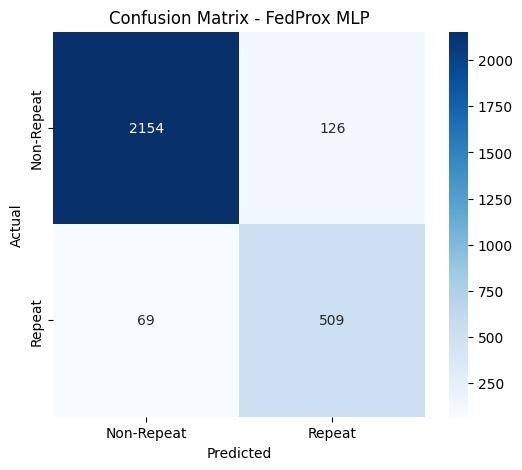

In [ ]:
# ========================================================
# CONFUSION MATRIX
# ========================================================

cm = confusion_matrix(y_global_test, y_pred)

plt.figure(figsize=(6,5))

sns.heatmap(cm,
            annot=True,
            fmt='d',
            cmap="Blues",
            xticklabels=["Non-Repeat","Repeat"],
            yticklabels=["Non-Repeat","Repeat"])

plt.title("Confusion Matrix - FedProx MLP")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

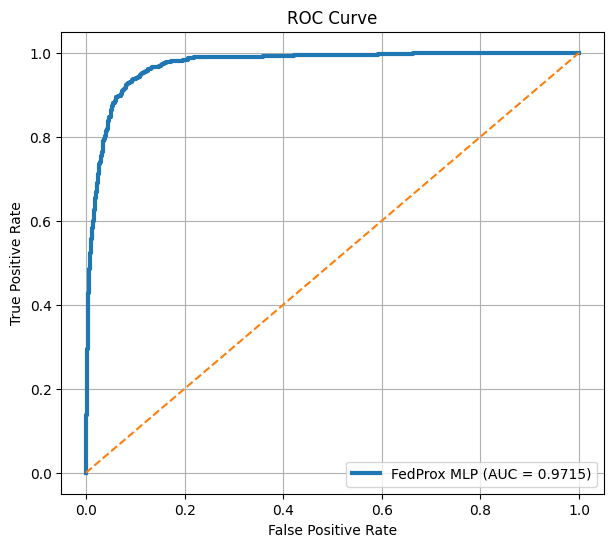

In [ ]:
# ========================================================
# ROC CURVE
# ========================================================

fpr, tpr, thresholds = roc_curve(y_global_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(7,6))

plt.plot(fpr, tpr,
         linewidth=3,
         label=f"FedProx MLP (AUC = {roc_auc:.4f})")

plt.plot([0,1],[0,1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("ROC Curve")

plt.legend()
plt.grid(True)

plt.show()

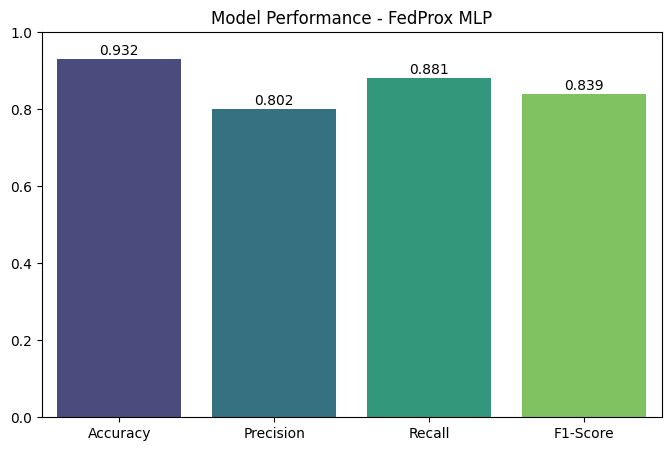

In [ ]:
# ========================================================
# MODEL PERFORMANCE BAR CHART
# ========================================================

metric_names = list(metrics.keys())
metric_values = list(metrics.values())

plt.figure(figsize=(8,5))

sns.barplot(
    x=metric_names,
    y=metric_values,
    palette="viridis"
)

for i,v in enumerate(metric_values):
    plt.text(i, v+0.01, f"{v:.3f}", ha='center')

plt.ylim(0,1)
plt.title("Model Performance - FedProx MLP")

plt.show()

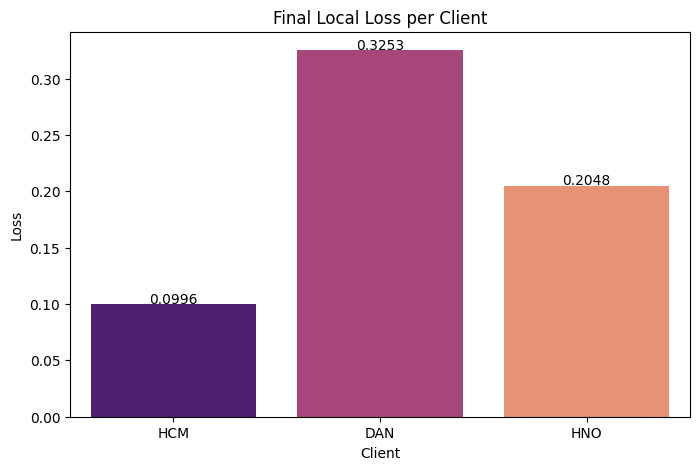

In [ ]:
# ========================================================
# CLIENT LOSS COMPARISON
# ========================================================

final_losses = [client_loss_history[ck][-1] for ck in client_keys]

plt.figure(figsize=(8,5))

sns.barplot(
    x=client_keys,
    y=final_losses,
    palette="magma"
)

for i,v in enumerate(final_losses):
    plt.text(i, v+0.001, f"{v:.4f}", ha='center')

plt.title("Final Local Loss per Client")
plt.xlabel("Client")
plt.ylabel("Loss")

plt.show()

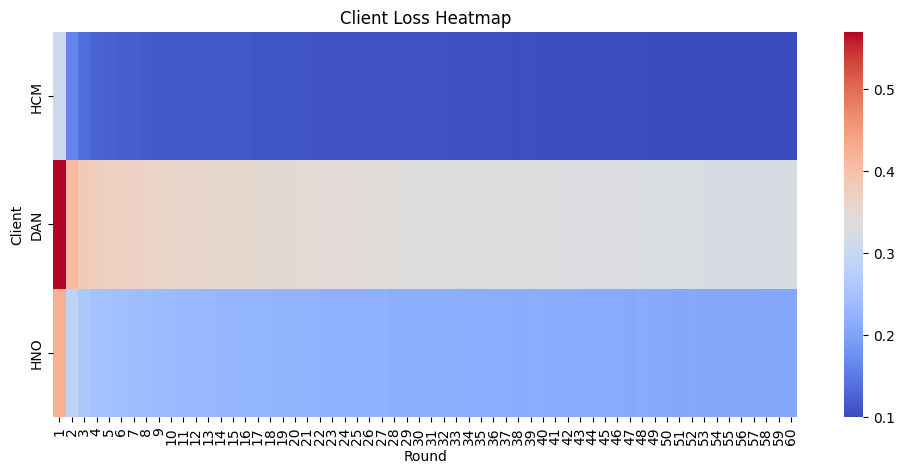

In [ ]:
# ========================================================
# CLIENT LOSS HEATMAP
# ========================================================

loss_matrix = np.array([
    client_loss_history[ck] for ck in client_keys
])

plt.figure(figsize=(12,5))

sns.heatmap(
    loss_matrix,
    cmap="coolwarm",
    xticklabels=range(1,num_rounds+1),
    yticklabels=client_keys
)

plt.title("Client Loss Heatmap")
plt.xlabel("Round")
plt.ylabel("Client")

plt.show()

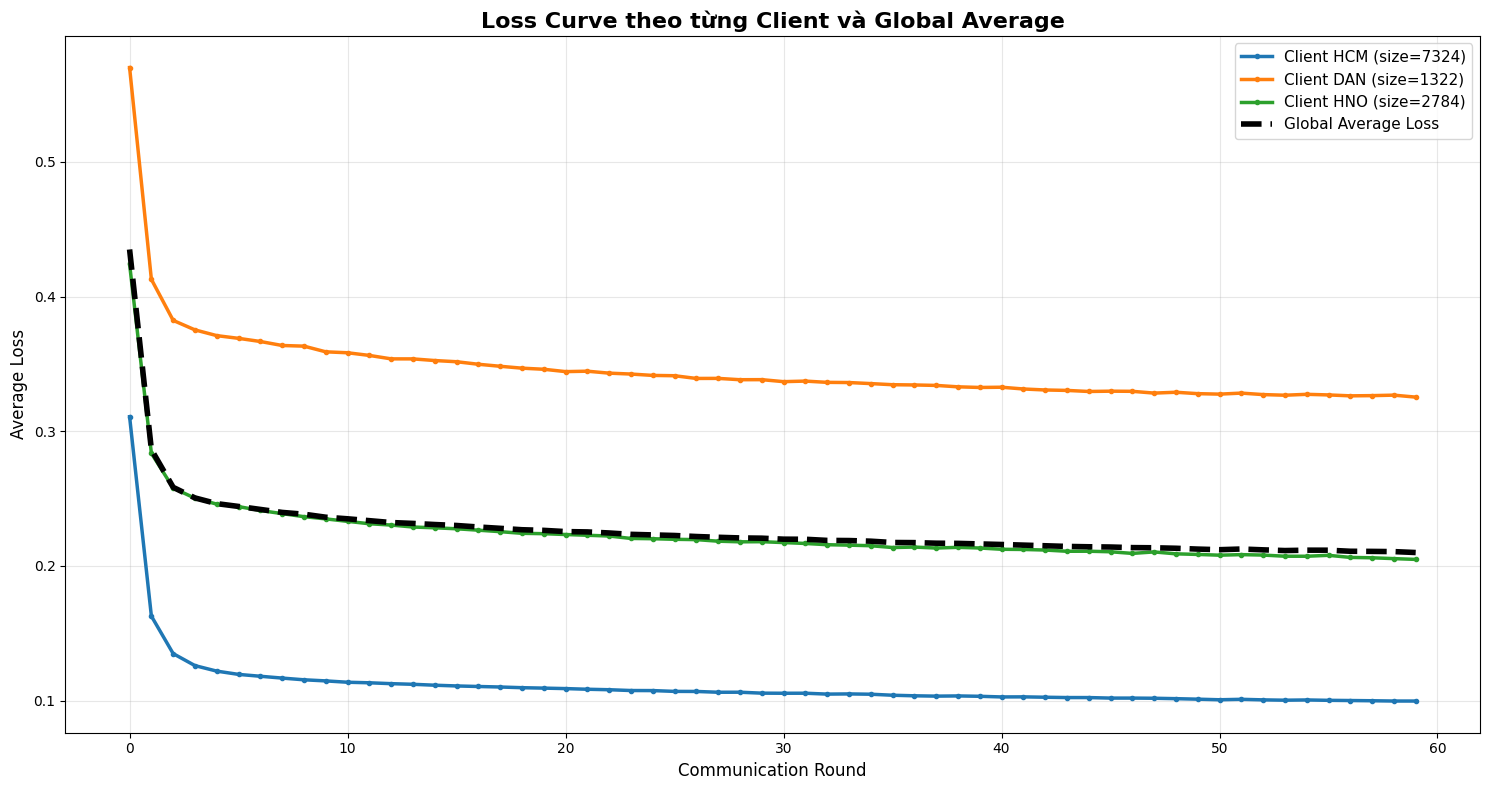

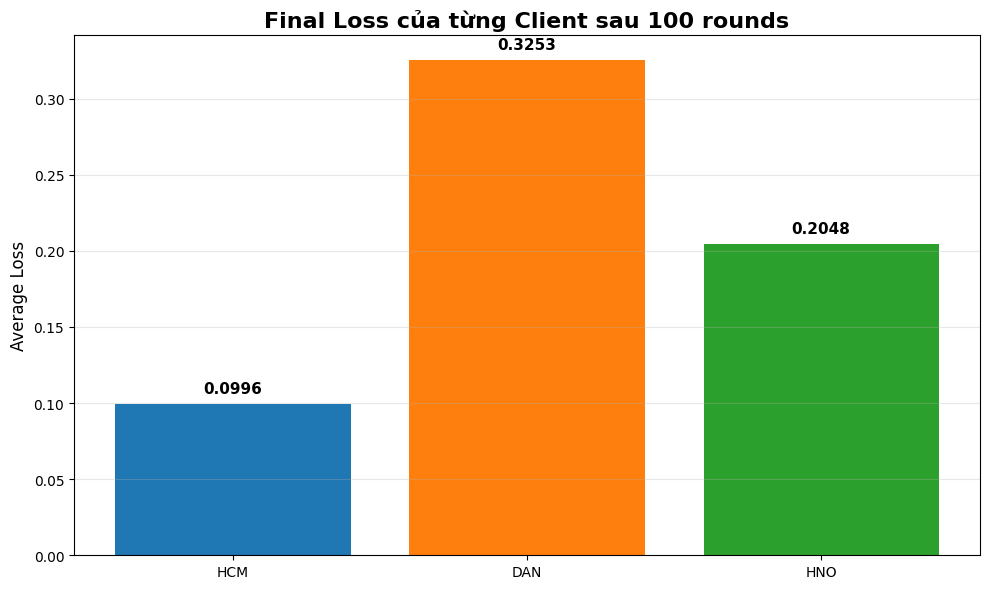


Best threshold found: 0.39


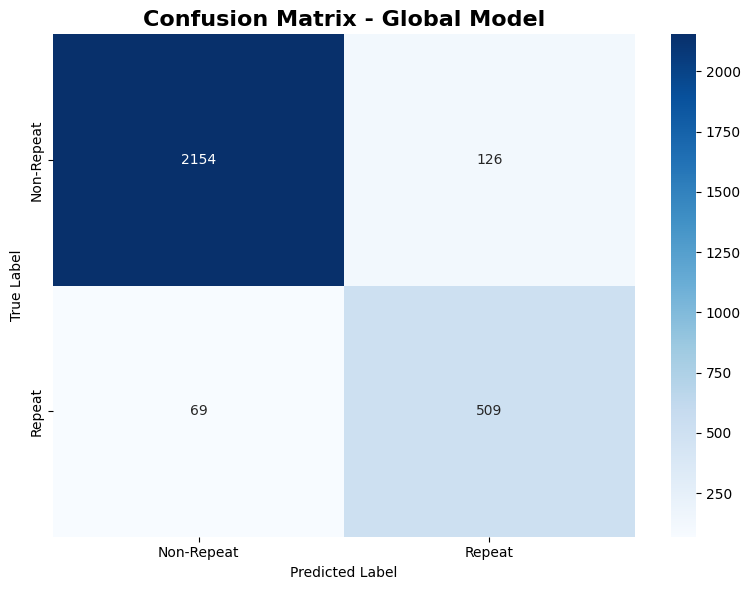

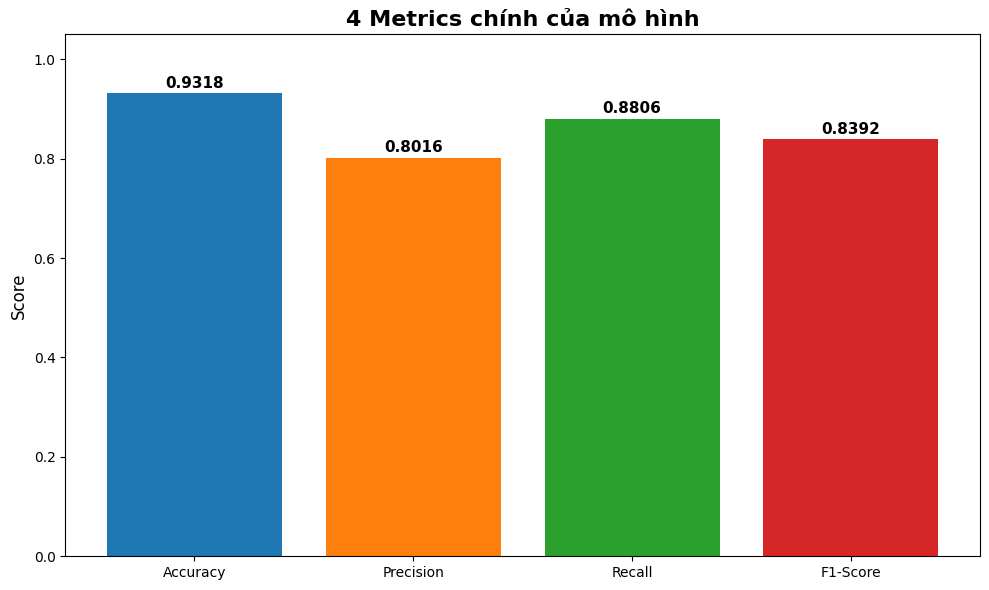

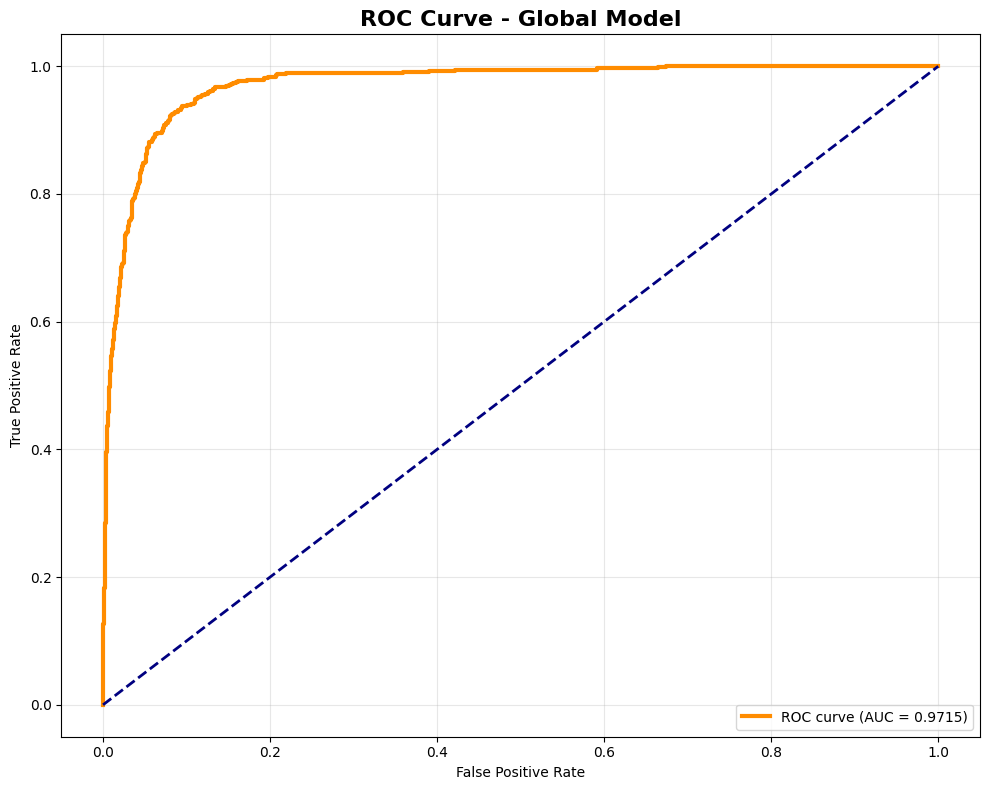


FINAL GLOBAL MODEL PERFORMANCE
Accuracy    : 0.9318
Precision   : 0.8016
Recall      : 0.8806
F1-Score    : 0.8392
AUC         : 0.9715


In [ ]:
# 1. Loss Curve từng Client + Global
plt.figure(figsize=(15, 8))
colors = {'HCM': '#1f77b4', 'DAN': '#ff7f0e', 'HNO': '#2ca02c'}

for ck in client_keys:
    plt.plot(client_loss_history[ck], label=f'Client {ck} (size={clients_data[ck]["size"]})',
             linewidth=2.5, color=colors[ck], marker='o', markersize=3)

plt.plot(global_loss_history, label='Global Average Loss',
         color='black', linewidth=4, linestyle='--')

plt.title('Loss Curve theo từng Client và Global Average',
          fontsize=16, fontweight='bold')
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# 2. Loss cuối cùng theo Client (Bar chart)
final_losses = [client_loss_history[ck][-1] for ck in client_keys]
plt.figure(figsize=(10, 6))
bars = plt.bar(client_keys, final_losses, color=[colors[ck] for ck in client_keys])
plt.title('Final Loss của từng Client sau 100 rounds', fontsize=16, fontweight='bold')
plt.ylabel('Average Loss', fontsize=12)
for bar, loss in zip(bars, final_losses):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{loss:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.show()

# 3. Confusion Matrix + Metrics
metrics, y_pred_proba, y_pred = evaluate_model(global_model, X_global_test, y_global_test)

cm = confusion_matrix(y_global_test, y_pred)
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Repeat', 'Repeat'],
            yticklabels=['Non-Repeat', 'Repeat'])
plt.title('Confusion Matrix - Global Model', fontsize=16, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.tight_layout()
plt.show()

# 4. Bar chart 4 Metrics
metric_names = list(metrics.keys())
metric_values = list(metrics.values())

plt.figure(figsize=(10, 6))
bars = plt.bar(metric_names, metric_values, color=['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728'])
plt.title('4 Metrics chính của mô hình', fontsize=16, fontweight='bold')
plt.ylabel('Score', fontsize=12)
for bar, val in zip(bars, metric_values):
    plt.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.005,
             f'{val:.4f}', ha='center', va='bottom', fontsize=11, fontweight='bold')
plt.ylim(0, 1.05)
plt.tight_layout()
plt.show()

# 5. ROC Curve
fpr, tpr, _ = roc_curve(y_global_test, y_pred_proba)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(10, 8))
plt.plot(fpr, tpr, color='darkorange', lw=3, label=f'ROC curve (AUC = {roc_auc:.4f})')
plt.plot([0, 1], [0, 1], color='navy', lw=2, linestyle='--')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('ROC Curve - Global Model', fontsize=16, fontweight='bold')
plt.legend(loc="lower right")
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

# In metrics
print("\n" + "="*60)
print("FINAL GLOBAL MODEL PERFORMANCE")
print("="*60)
for k, v in metrics.items():
    print(f"{k:12}: {v:.4f}")
print(f"AUC         : {roc_auc:.4f}")
print("="*60)

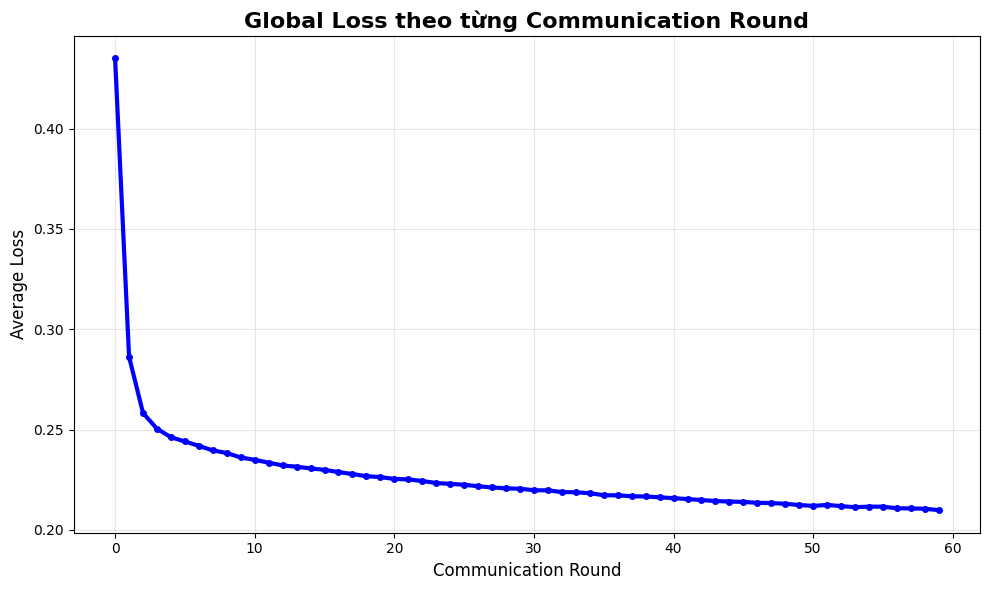

In [ ]:
plt.figure(figsize=(10, 6))

plt.plot(global_loss_history,
         label='Global Loss',
         color='blue',
         linewidth=3,
         marker='o',
         markersize=4)

plt.title('Global Loss theo từng Communication Round',
          fontsize=16, fontweight='bold')

plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)

plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

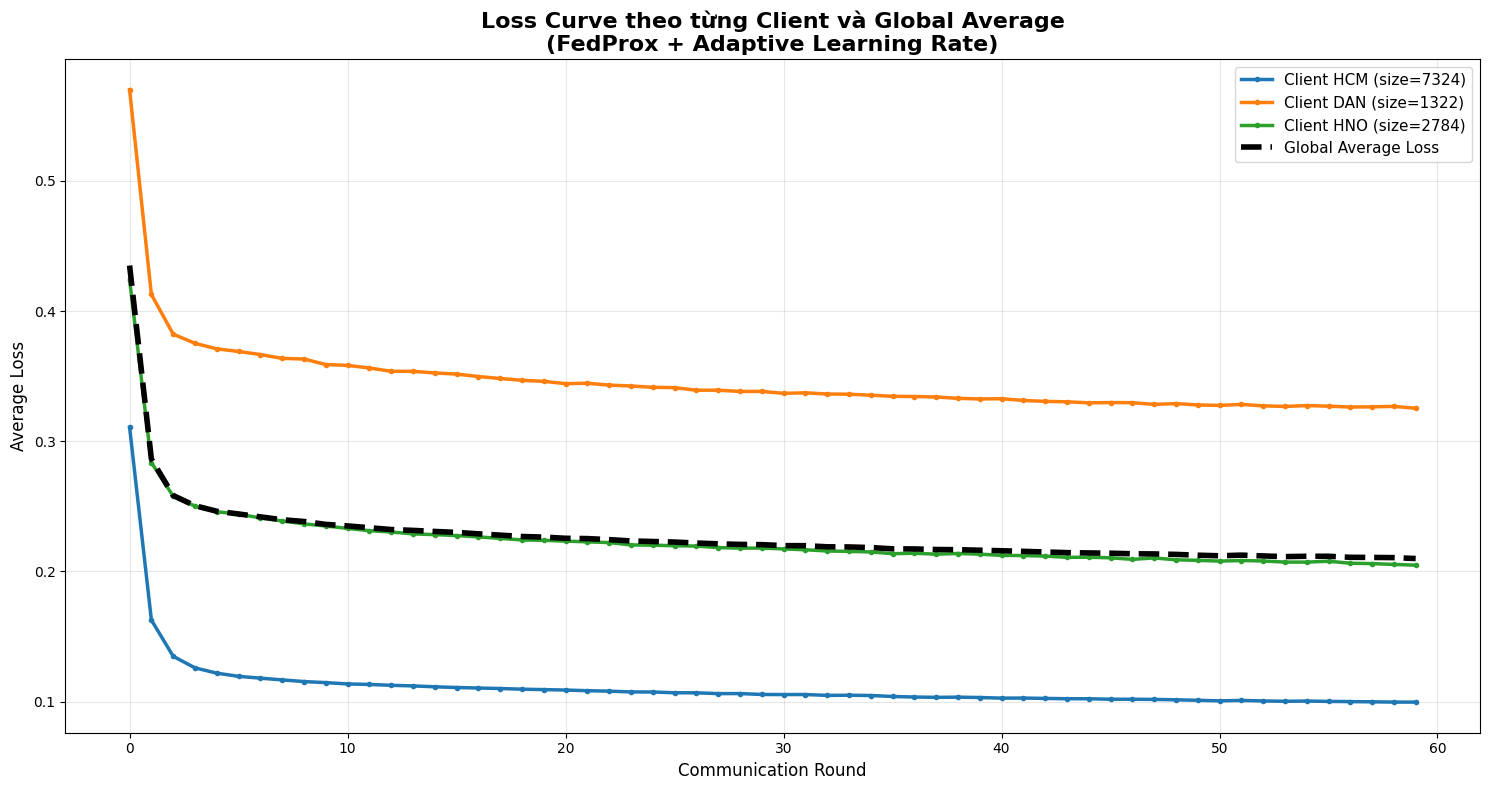


✅ Hoàn tất training với Adaptive Learning Rate!


In [ ]:
plt.figure(figsize=(15, 8))
colors = {'HCM': '#1f77b4', 'DAN': '#ff7f0e', 'HNO': '#2ca02c'}

for ck in client_keys:
    plt.plot(client_loss_history[ck],
             label=f'Client {ck} (size={clients_data[ck]["size"]})',
             linewidth=2.5, color=colors[ck], marker='o', markersize=3)

plt.plot(global_loss_history, label='Global Average Loss',
         color='black', linewidth=4, linestyle='--')

plt.title('Loss Curve theo từng Client và Global Average\n(FedProx + Adaptive Learning Rate)',
          fontsize=16, fontweight='bold')
plt.xlabel('Communication Round', fontsize=12)
plt.ylabel('Average Loss', fontsize=12)
plt.legend(fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

print("\n✅ Hoàn tất training với Adaptive Learning Rate!")


=== CLIENT DATA DISTRIBUTION (Non-IID Check) ===
  client  size  repeat_rate  non_repeat_rate
0    HCM  7324     0.116739         0.883260
1    DAN  1322     0.554463         0.445537
2    HNO  2784     0.259698         0.740302


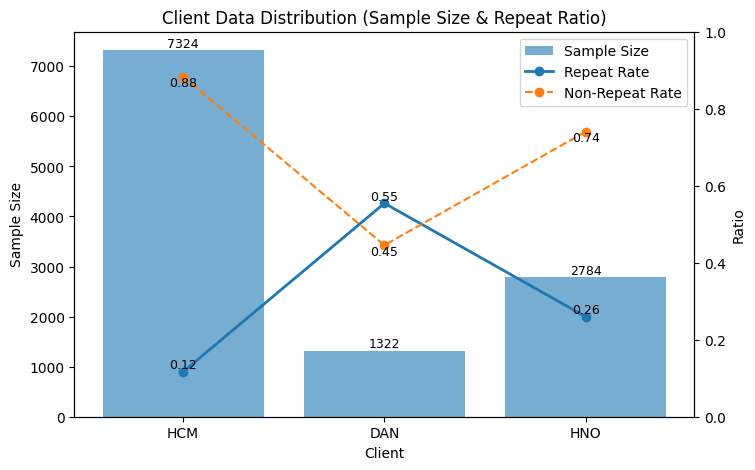

In [ ]:
print("\n=== CLIENT DATA DISTRIBUTION (Non-IID Check) ===")

heterogeneity_stats = []

for ck in client_keys:

    y_train = clients_data[ck]['y_train']

    size = len(y_train)
    repeat = np.sum(y_train)
    non_repeat = size - repeat

    repeat_rate = repeat / size
    non_repeat_rate = non_repeat / size

    heterogeneity_stats.append({
        "client": ck,
        "size": size,
        "repeat_rate": repeat_rate,
        "non_repeat_rate": non_repeat_rate
    })

heterogeneity_df = pd.DataFrame(heterogeneity_stats)

print(heterogeneity_df)

# ======================================================
# VISUALIZATION
# ======================================================

fig, ax1 = plt.subplots(figsize=(8,5))

# ----- BAR: SAMPLE SIZE -----
bars = ax1.bar(
    heterogeneity_df["client"],
    heterogeneity_df["size"],
    alpha=0.6,
    label="Sample Size"
)

ax1.set_ylabel("Sample Size")
ax1.set_xlabel("Client")

# Label sample size
for bar in bars:
    height = bar.get_height()
    ax1.text(
        bar.get_x() + bar.get_width()/2,
        height,
        f"{int(height)}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# ----- LINE: RATIOS -----
ax2 = ax1.twinx()

line1 = ax2.plot(
    heterogeneity_df["client"],
    heterogeneity_df["repeat_rate"],
    marker="o",
    linewidth=2,
    label="Repeat Rate"
)

line2 = ax2.plot(
    heterogeneity_df["client"],
    heterogeneity_df["non_repeat_rate"],
    marker="o",
    linestyle="--",
    label="Non-Repeat Rate"
)

ax2.set_ylabel("Ratio")
ax2.set_ylim(0,1)

# Label repeat rate
for i, val in enumerate(heterogeneity_df["repeat_rate"]):
    ax2.text(
        i,
        val,
        f"{val:.2f}",
        ha='center',
        va='bottom',
        fontsize=9
    )

# Label non-repeat rate
for i, val in enumerate(heterogeneity_df["non_repeat_rate"]):
    ax2.text(
        i,
        val,
        f"{val:.2f}",
        ha='center',
        va='top',
        fontsize=9
    )

# ----- TITLE -----
plt.title("Client Data Distribution (Sample Size & Repeat Ratio)")

# ----- LEGEND -----
lines, labels = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()

ax2.legend(lines + lines2, labels + labels2, loc="upper right")

plt.show()

In [ ]:
import pandas as pd
import numpy as np
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

print("\nĐang chuẩn bị dữ liệu cho Power BI...")

# ===================================================================
# 1. CHUẨN HÓA DỮ LIỆU BUSINESS
# ===================================================================
customer_df = customer_df.copy()

# Chuẩn hóa monetary (ưu tiên gross_sales)
customer_df['monetary'] = customer_df.get('gross_sales',
                             customer_df.get('net_monetary', 0))

# ARPU
if 'frequency' in customer_df.columns:
    customer_df['ARPU'] = customer_df['monetary'] / customer_df['frequency'].replace(0, 1)
else:
    customer_df['ARPU'] = 0

# ===================================================================
# 2. RFM CLUSTERING (AUTO SEGMENT)
# ===================================================================
print("Đang thực hiện phân khúc khách hàng bằng RFM + KMeans...")

rfm_cols = ['recency', 'frequency', 'monetary']
rfm_df = customer_df[['customer_code'] + rfm_cols].copy()

# Clean data
rfm_df['frequency'] = rfm_df['frequency'].clip(lower=0)
rfm_df['monetary'] = rfm_df['monetary'].clip(lower=0)
rfm_df['recency']  = rfm_df['recency'].clip(lower=0, upper=365)

# Log transform
rfm_df['log_frequency'] = np.log1p(rfm_df['frequency'])
rfm_df['log_monetary']  = np.log1p(rfm_df['monetary'])
rfm_df['recency_score'] = rfm_df['recency']

features = ['recency_score', 'log_frequency', 'log_monetary']

# Scale
scaler = StandardScaler()
X_scaled = scaler.fit_transform(rfm_df[features])

# KMeans
kmeans = KMeans(n_clusters=4, random_state=42, n_init=10)
rfm_df['Cluster'] = kmeans.fit_predict(X_scaled)

# Centroid summary
cluster_summary = rfm_df.groupby('Cluster').agg({
    'recency': 'mean',
    'frequency': 'mean',
    'monetary': 'mean',
    'customer_code': 'count'
}).round(2)

print("\nCentroid của các phân khúc:")
print(cluster_summary)

# Gán tên segment (có thể refine sau khi xem centroid)
cluster_names = {
    0: 'Low Value',
    1: 'Medium',
    2: 'High Value',
    3: 'VIP'
}

rfm_df['Customer_Value_Segment'] = rfm_df['Cluster'].map(cluster_names)

# Merge lại
customer_df = customer_df.merge(
    rfm_df[['customer_code', 'Customer_Value_Segment']],
    on='customer_code',
    how='left'
)

# ===================================================================
# 3. TẠO DATASET CHO POWER BI
# ===================================================================
pred_df = pd.DataFrame({
    'customer_code': global_test['customer_code'].values,
    'sales_district': global_test['mode_sales_district'].values,
    'Pred_Repeat_Prob': y_pred_proba,
    'Pred_Repeat': y_pred,
    'Actual_Repeat': y_global_test.astype(int)
})

business_cols = [
    'frequency', 'ARPU', 'net_monetary', 'gross_sales', 'monetary',
    'avg_basket_value_positive', 'product_diversity', 'tenure_days',
    'cancel_ratio', 'cancel_count', 'credit_issue_rate',
    'recency', 'Customer_Value_Segment'
]

available_cols = [col for col in business_cols if col in customer_df.columns]

pred_df = pred_df.merge(
    customer_df[['customer_code'] + available_cols],
    on='customer_code',
    how='left'
)

# Fill NA
pred_df['ARPU'] = pred_df['ARPU'].fillna(0)
pred_df['Customer_Value_Segment'] = pred_df['Customer_Value_Segment'].fillna('Low Value')
pred_df['monetary'] = pred_df['monetary'].fillna(0)

# ===================================================================
# 4. INSIGHT & ACTION
# ===================================================================
pred_df['Expected_Retention_Revenue'] = pred_df['Pred_Repeat_Prob'] * pred_df['monetary']
pred_df['Expected_Churn_Loss']        = (1 - pred_df['Pred_Repeat_Prob']) * pred_df['monetary']

# Risk level
pred_df['Risk_Level'] = pd.cut(
    pred_df['Pred_Repeat_Prob'],
    bins=[0, 0.3, 0.6, 0.8, 1.0],
    labels=['Rất Cao (Cần can thiệp)', 'Cao', 'Trung bình', 'Thấp']
)

# Recommendation
pred_df['Action_Recommendation'] = np.select(
    [
        pred_df['Pred_Repeat_Prob'] < 0.40,
        pred_df['Pred_Repeat_Prob'] < 0.70
    ],
    [
        'Can thiệp khẩn cấp (ưu đãi mạnh)',
        'Gửi ưu đãi giữ chân'
    ],
    default='Duy trì & Cross-sell / Upsell'
)

# ===================================================================
# 5. EXPORT FILE
# ===================================================================
pred_df.to_csv('PowerBI_Prediction.csv', index=False, encoding='utf-8-sig')
print(f"Xuất file chính: PowerBI_Prediction.csv ({len(pred_df):,} khách hàng)")

# Summary
summary_by_district = pred_df.groupby(['sales_district', 'Customer_Value_Segment']).agg(
    So_Khach=('customer_code', 'nunique'),
    Ty_Le_Repeat_Thuc=('Actual_Repeat', 'mean'),
    Ty_Le_Repeat_DuDoan=('Pred_Repeat_Prob', 'mean'),
    Doanh_Thu_Giu_Chan=('Expected_Retention_Revenue', 'sum'),
    Thiet_Hai_Du_Kien=('Expected_Churn_Loss', 'sum')
).round(4)

summary_by_district.to_csv('PowerBI_Summary_By_District_Segment.csv', encoding='utf-8-sig')
print("Xuất file summary theo khu vực & phân khúc")

# Top risk customers
top_risk = pred_df[
    pred_df['Risk_Level'].astype(str).str.contains('Rất Cao|Cao', na=False)
].sort_values('Expected_Churn_Loss', ascending=False).head(500)

top_risk.to_csv('PowerBI_Top_Risk_Customers.csv', index=False, encoding='utf-8-sig')
print("Xuất Top 500 khách hàng rủi ro cao")

print("\nHOÀN TẤT! Sẵn sàng import vào Power BI ")



Đang chuẩn bị dữ liệu cho Power BI...
Đang thực hiện phân khúc khách hàng bằng RFM + KMeans...

Centroid của các phân khúc:
         recency  frequency      monetary  customer_code
Cluster                                                 
0         308.37      16.90  1.260334e+08           3718
1          39.76     160.02  4.877287e+09           2412
2         339.71       2.35  4.452353e+06           5800
3          51.05      14.75  1.131056e+08           2358
Xuất file chính: PowerBI_Prediction.csv (2,858 khách hàng)
Xuất file summary theo khu vực & phân khúc
Xuất Top 500 khách hàng rủi ro cao

HOÀN TẤT! Sẵn sàng import vào Power BI 


In [ ]:
torch.save(global_model.state_dict(), "global_model.pth")

In [ ]:
from sklearn.metrics import f1_score, precision_score, recall_score, accuracy_score

def evaluate_each_client(global_model, clients_data):
    global_model.eval()

    results = {}

    for ck in clients_data.keys():
        X_test = clients_data[ck]['X_test']
        y_test = clients_data[ck]['y_test']

        with torch.no_grad():
            logits = global_model(torch.tensor(X_test, dtype=torch.float32)).squeeze()
            y_prob = torch.sigmoid(logits).numpy()
        best_threshold = 0.45

        y_pred = (y_prob >= best_threshold).astype(int)

        results[ck] = {
            "Accuracy": accuracy_score(y_test, y_pred),
            "Precision": precision_score(y_test, y_pred, zero_division=0),
            "Recall": recall_score(y_test, y_pred, zero_division=0),
            "F1": f1_score(y_test, y_pred, zero_division=0)
        }

    return results

In [ ]:
client_metrics = evaluate_each_client(global_model, clients_data)

for ck, metrics in client_metrics.items():
    print(f"\nClient {ck}:")
    for k, v in metrics.items():
        print(f"  {k}: {v:.4f}")


Client HCM:
  Accuracy: 0.9487
  Precision: 0.7804
  Recall: 0.7804
  F1: 0.7804

Client DAN:
  Accuracy: 0.9003
  Precision: 0.8906
  Recall: 0.9344
  F1: 0.9120

Client HNO:
  Accuracy: 0.8966
  Precision: 0.7633
  Recall: 0.8729
  F1: 0.8144


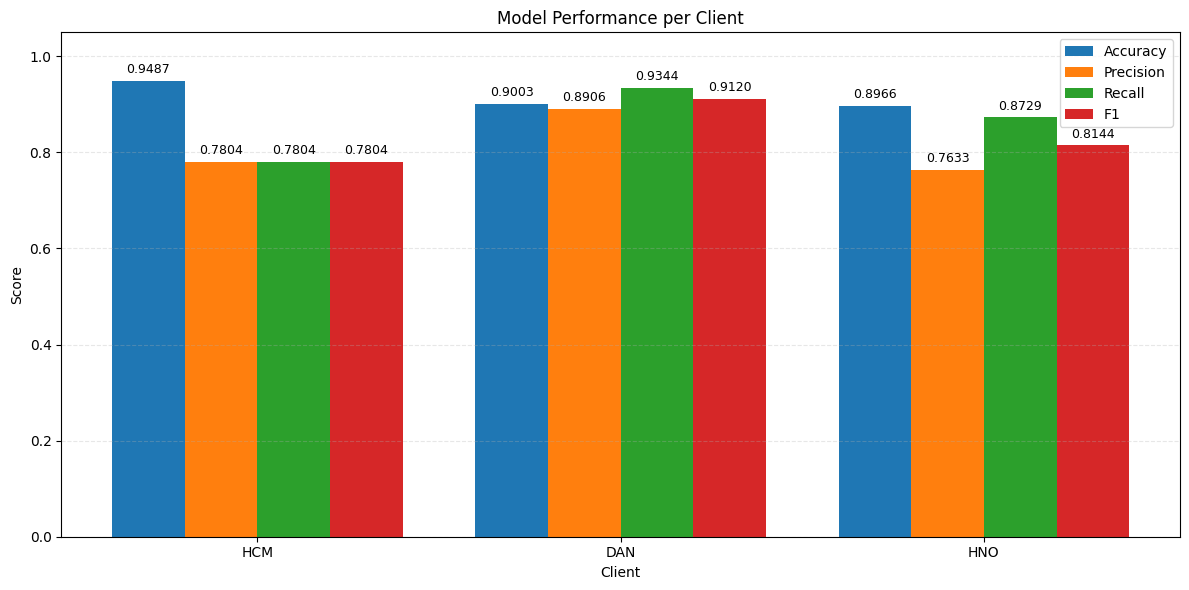

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# ===== Chuẩn bị dữ liệu =====
metrics_names = ["Accuracy", "Precision", "Recall", "F1"]
n_clients = len(client_keys)

# Tạo matrix: rows = client, cols = metrics
data = np.array([
    [client_metrics[ck]["Accuracy"],
     client_metrics[ck]["Precision"],
     client_metrics[ck]["Recall"],
     client_metrics[ck]["F1"]]
    for ck in client_keys
])

# ===== Plot =====
x = np.arange(n_clients)
width = 0.2

plt.figure(figsize=(12,6))

bars = []
for i, metric in enumerate(metrics_names):
    bar = plt.bar(x + i*width, data[:, i], width, label=metric)
    bars.append(bar)

# ===== Data label =====
for bar_group in bars:
    for bar in bar_group:
        height = bar.get_height()
        plt.text(
            bar.get_x() + bar.get_width()/2,
            height + 0.01,
            f"{height:.4f}",
            ha='center',
            va='bottom',
            fontsize=9
        )

# ===== Format =====
plt.xticks(x + width*1.5, client_keys)
plt.ylim(0, 1.05)
plt.title("Model Performance per Client")
plt.xlabel("Client")
plt.ylabel("Score")
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.3)

plt.tight_layout()
plt.show()

🔄 Đang chuẩn bị tính SHAP values...
X_global_test shape: (2858, 69)
⚠️  feature_names (66) ≠ X columns (69)
Đã thêm 3 feature placeholder
Final feature_names length: 69
Đang tính SHAP values... (Deep SHAP)
SHAP values shape: (2858, 69)

TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT THEO SHAP
                         Feature  Mean_Abs_SHAP  Mean_SHAP
0          mode_order_source_EDC        3.61612    1.08692
1         mode_order_source_CALL        0.59728   -0.05858
2                   cancel_count        0.40283   -0.03700
3       mode_warehouse_code_3057        0.34645    0.27545
4              mode_ar_term_E013        0.32935    0.02456
5   has_positive_purchase_before        0.25973   -0.07400
6                    tenure_days        0.22846    0.04550
7              mode_ar_term_C012        0.17685   -0.02212
8       mode_sales_type_code_NOR        0.17335    0.17329
9                      frequency        0.16381    0.01675
10         mode_order_source_TOS        0.12746   -0.00037
11      mode

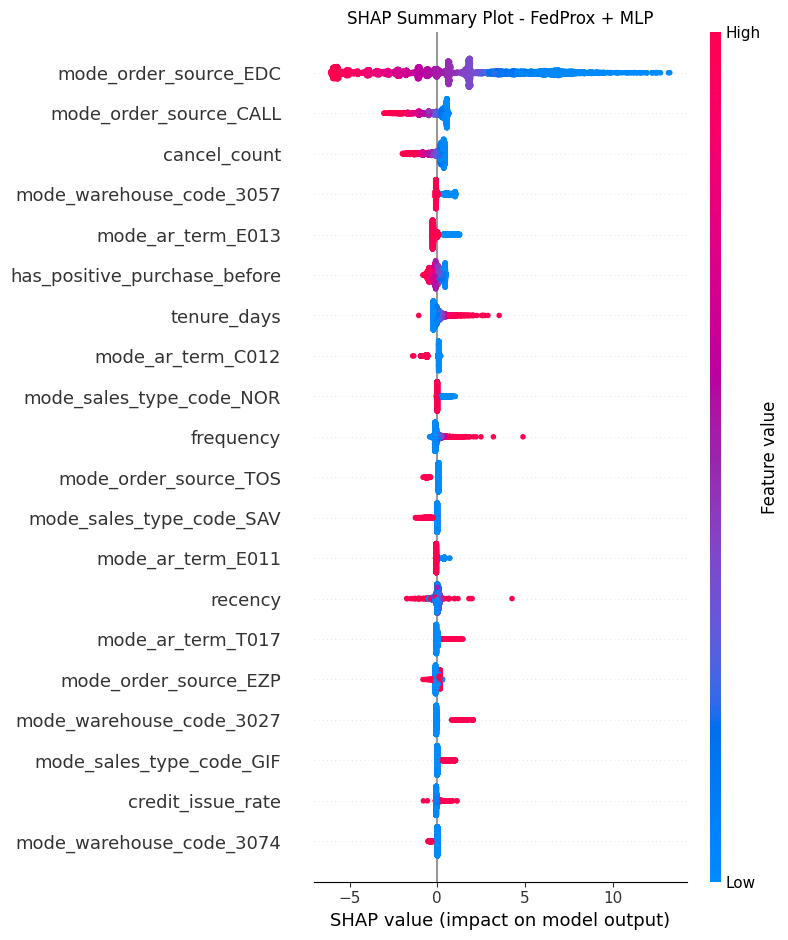

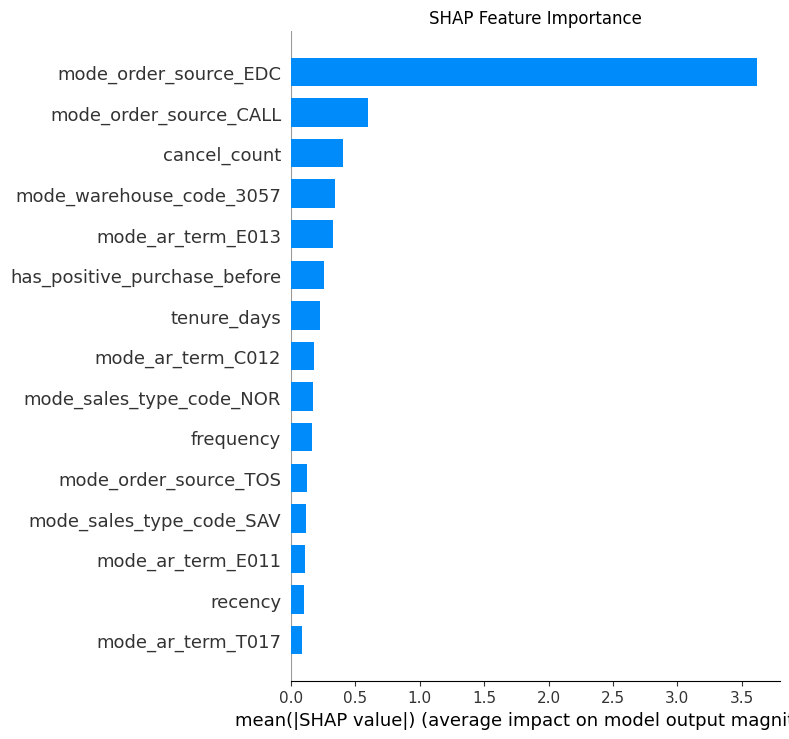

In [ ]:
import shap
import torch
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd

print("🔄 Đang chuẩn bị tính SHAP values...")

# ====================== 1. Chuẩn bị X_test và feature_names CHÍNH XÁC ======================
X_test_tensor = torch.tensor(X_global_test, dtype=torch.float32)

print(f"X_global_test shape: {X_global_test.shape}")

# Cách tạo feature_names AN TOÀN và CHÍNH XÁC nhất
feature_names = numerical_cols.copy()

for col in cat_cols:
    # Lấy tất cả categories từ encoder
    categories = encoders[col].categories_[0]
    for cat in categories:
        feature_names.append(f"{col}_{cat}")

# Kiểm tra và điều chỉnh nếu vẫn không khớp (rất quan trọng)
if len(feature_names) != X_global_test.shape[1]:
    print(f"⚠️  feature_names ({len(feature_names)}) ≠ X columns ({X_global_test.shape[1]})")

    # Nếu thừa hoặc thiếu, chúng ta sẽ tạo feature_names theo số cột thực tế
    if len(feature_names) < X_global_test.shape[1]:
        # Thêm placeholder cho các cột thiếu
        missing = X_global_test.shape[1] - len(feature_names)
        for i in range(missing):
            feature_names.append(f"unknown_feature_{i}")
        print(f"Đã thêm {missing} feature placeholder")
    else:
        # Cắt bớt nếu thừa
        feature_names = feature_names[:X_global_test.shape[1]]
        print(f"Đã cắt feature_names xuống còn {len(feature_names)}")

print(f"Final feature_names length: {len(feature_names)}")

# ====================== 2. Tính SHAP ======================
background = torch.tensor(X_global_test[:250], dtype=torch.float32)   # Giảm để nhanh

explainer = shap.DeepExplainer(global_model, background)

print("Đang tính SHAP values... (Deep SHAP)")
shap_values = explainer.shap_values(X_test_tensor)

# Xử lý shape
if isinstance(shap_values, list):
    shap_values = shap_values[0]

shap_values = np.array(shap_values)

if shap_values.ndim == 3:
    shap_values = shap_values.squeeze(axis=-1)

print(f"SHAP values shape: {shap_values.shape}")

# ====================== 3. Tạo bảng Importance (ĐÃ SỬA) ======================
mean_abs_shap = np.abs(shap_values).mean(axis=0)

# Đảm bảo độ dài tuyệt đối bằng nhau
n_features = X_global_test.shape[1]
feature_names = feature_names[:n_features]
mean_abs_shap = mean_abs_shap[:n_features]

shap_importance = pd.DataFrame({
    'Feature': feature_names,
    'Mean_Abs_SHAP': mean_abs_shap,
    'Mean_SHAP': shap_values.mean(axis=0)[:n_features]
}).sort_values(by='Mean_Abs_SHAP', ascending=False).reset_index(drop=True)

print("\n" + "="*80)
print("TOP 15 ĐẶC TRƯNG QUAN TRỌNG NHẤT THEO SHAP")
print("="*80)
print(shap_importance.head(15).round(5))

shap_importance.to_csv('SHAP_Feature_Importance_FedProx_MLP.csv', index=False)

# ====================== 4. Vẽ biểu đồ ======================
plt.figure(figsize=(14, 10))
shap.summary_plot(shap_values, X_global_test,
                  feature_names=feature_names,
                  plot_type="dot", show=False, max_display=20)
plt.title("SHAP Summary Plot - FedProx + MLP")
plt.tight_layout()
plt.show()

plt.figure(figsize=(12, 8))
shap.summary_plot(shap_values, X_global_test,
                  feature_names=feature_names,
                  plot_type="bar", show=False, max_display=15)
plt.title("SHAP Feature Importance")
plt.tight_layout()
plt.show()